# Student Dropout Prediction — Higher Education vs A Level or Below
**Project : UFCEKP-30-3 Data Science and AI Individual Project**

This notebook runs the full 4th-model pipeline on two filtered sub-groups from the Open University studentInfo dataset:
- **Higher Education** — HE Qualification + Post Graduate Qualification (n = 5,043)
- **A Level or Below** — A Level or Equivalent + Lower Than A Level + No Formal Quals (n = 27,550)

Each group is trained and evaluated independently with the same pipeline:
Base models → Ensembles → Binary Classifier → 10-Fold CV → Learning Curves → Final Summary

# ─────────────────────────────────────────────────────────────────────────────
# 0.  IMPORTS & CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.ensemble         import (RandomForestClassifier,
                                       GradientBoostingClassifier,
                                       VotingClassifier,
                                       StackingClassifier)
from sklearn.metrics          import (classification_report,
                                       confusion_matrix,
                                       ConfusionMatrixDisplay,
                                       roc_auc_score,
                                       roc_curve,
                                       f1_score,
                                       accuracy_score)
from sklearn.utils            import resample
import copy

# ── Paths — put both CSVs in the same folder as this notebook ─────────────────
HE_PATH      = 'HE_model_ready.csv'       # Higher Education group
AL_PATH      = 'ALevel_model_ready.csv'   # A Level or Below group
OUTPUT_DIR   = '.'                         # folder where PNG plots are saved
RANDOM_SEED  = 42
# ─────────────────────────────────────────────────────────────────────────────

GROUP_NAMES  = ['Higher Education', 'A Level or Below']
GROUP_COLORS = ['#1D9E75', '#E15759']      # green = HE,  red = A Level


def section(title):
    print('\n' + '=' * 70)
    print(f'  {title}')
    print('=' * 70)


def balance_training(X_train, y_train, random_state=RANDOM_SEED):
    """Oversample minority class to match majority class count."""
    df = X_train.reset_index(drop=True).copy()
    df['__label__']  = y_train.reset_index(drop=True)
    majority_cls     = df['__label__'].value_counts().idxmax()
    majority_count   = df['__label__'].value_counts().max()
    parts = []
    for cls in df['__label__'].unique():
        subset = df[df['__label__'] == cls]
        if cls != majority_cls:
            subset = resample(subset, replace=True,
                              n_samples=majority_count,
                              random_state=random_state)
        parts.append(subset)
    balanced = pd.concat(parts).sample(frac=1, random_state=random_state)
    return (balanced.drop(columns=['__label__']),
            balanced['__label__'])


print('Imports OK')

Imports OK


# ─────────────────────────────────────────────────────────────────────────────
# 1.  LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
section('STEP 1 — LOADING DATA')

he_df = pd.read_csv(HE_PATH)
al_df = pd.read_csv(AL_PATH)

group_dfs = {
    'Higher Education': he_df,
    'A Level or Below': al_df,
}

for gname, gdf in group_dfs.items():
    print(f'\n{gname}')
    print(f'  Shape         : {gdf.shape}')
    print(f'  Missing values: {gdf.isnull().sum().sum()}')
    print(f'  Dropout rate  : {gdf["dropout"].mean():.1%}')
    print(f'  Class counts  : {gdf["dropout"].value_counts().to_dict()}  (0=Not Dropout, 1=Dropout)')


  STEP 1 — LOADING DATA

Higher Education
  Shape         : (5043, 11)
  Missing values: 0
  Dropout rate  : 26.9%
  Class counts  : {0: 3686, 1: 1357}  (0=Not Dropout, 1=Dropout)

A Level or Below
  Shape         : (27550, 11)
  Missing values: 0
  Dropout rate  : 31.9%
  Class counts  : {0: 18751, 1: 8799}  (0=Not Dropout, 1=Dropout)


# ─────────────────────────────────────────────────────────────────────────────
# 2.  EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────


  STEP 2 — EXPLORATORY DATA ANALYSIS


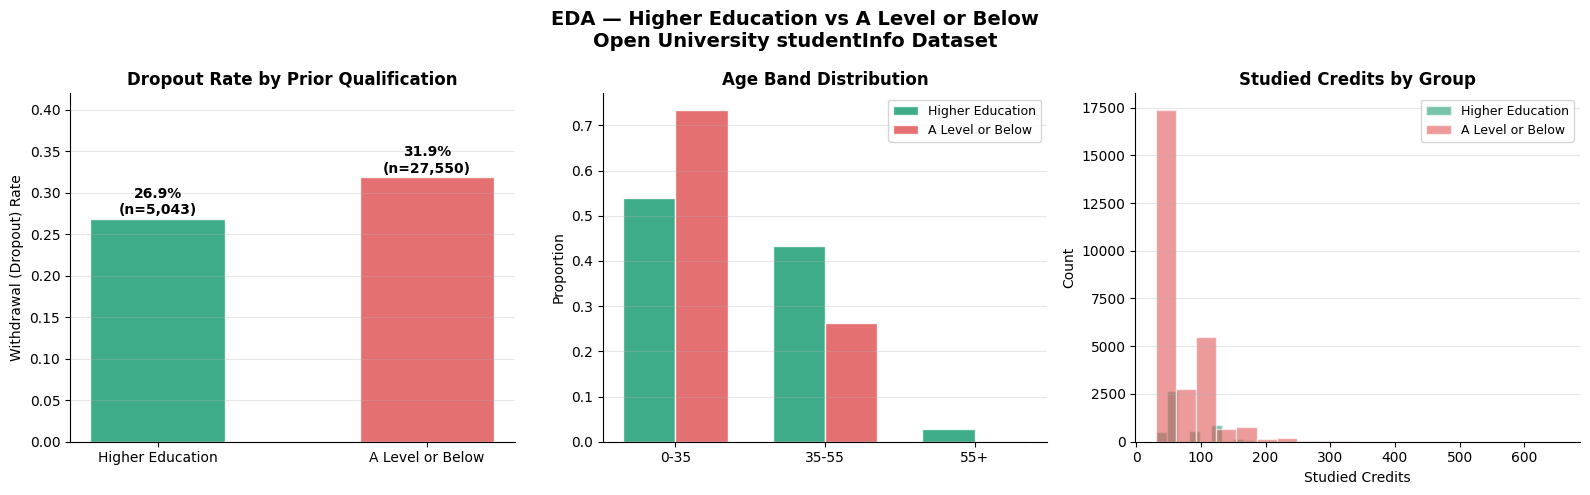

Saved: plot_eda_he_al.png


In [4]:
section('STEP 2 — EXPLORATORY DATA ANALYSIS')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — Higher Education vs A Level or Below\nOpen University studentInfo Dataset',
             fontsize=14, fontweight='bold')

# 2a. Dropout rate comparison
ax = axes[0]
rates = [group_dfs[g]['dropout'].mean() for g in GROUP_NAMES]
ns    = [len(group_dfs[g]) for g in GROUP_NAMES]
bars  = ax.bar(GROUP_NAMES, rates, color=GROUP_COLORS, alpha=0.85,
               edgecolor='white', width=0.5)
for bar, r, n in zip(bars, rates, ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{r:.1%}\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 0.42)
ax.set_ylabel('Withdrawal (Dropout) Rate')
ax.set_title('Dropout Rate by Prior Qualification', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
[ax.spines[s].set_visible(False) for s in ['top', 'right']]

# 2b. Age band distribution (encoded: 0=0-35, 1=35-55, 2=55<=)
ax = axes[1]
age_labels = ['0-35', '35-55', '55+']
x = np.arange(len(age_labels)); w = 0.35
for g, offset, color in zip(GROUP_NAMES, [-w/2, w/2], GROUP_COLORS):
    dist = group_dfs[g]['age_band'].value_counts(normalize=True).sort_index()
    vals = [dist.get(i, 0) for i in range(3)]
    ax.bar(x + offset, vals, w, label=g, color=color, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(age_labels)
ax.set_ylabel('Proportion')
ax.set_title('Age Band Distribution', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
[ax.spines[s].set_visible(False) for s in ['top', 'right']]

# 2c. studied_credits distribution
ax = axes[2]
for g, color in zip(GROUP_NAMES, GROUP_COLORS):
    ax.hist(group_dfs[g]['studied_credits'], bins=20, alpha=0.6,
            label=g, color=color, edgecolor='white')
ax.set_xlabel('Studied Credits')
ax.set_ylabel('Count')
ax.set_title('Studied Credits by Group', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
[ax.spines[s].set_visible(False) for s in ['top', 'right']]

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_eda_he_al.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_eda_he_al.png')

# ─────────────────────────────────────────────────────────────────────────────
# 3.  PREPROCESSING  (scale + stratified 80/20 split + oversample)
# ─────────────────────────────────────────────────────────────────────────────

In [5]:
section('STEP 3 — PREPROCESSING')

"""
DATA SPLIT DIAGRAM
──────────────────────────────────────────────────────────────
Each group processed independently:
│
├─ 80% TRAIN  ← fit scaler + models here
│    └─ Oversampled to balance dropout / non-dropout classes
│         └─ 5-fold CV used during training for stability check
│
└─ 20% TEST   ← never seen until final evaluation
──────────────────────────────────────────────────────────────
"""

group_data = {}   # stores all preprocessed data and results per group

for gname in GROUP_NAMES:
    gdf = group_dfs[gname].copy()

    X = gdf.drop(columns=['dropout'])
    y = gdf['dropout']

    # Scale on ALL data (used for 10-fold CV section)
    scaler_all   = StandardScaler()
    X_scaled_all = pd.DataFrame(scaler_all.fit_transform(X), columns=X.columns)

    # Stratified 80/20 split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled_all, y,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=y)

    # Oversample minority class in training set only
    X_train_bal, y_train_bal = balance_training(X_train, y_train)

    print(f'\n{gname}')
    print(f'  Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}')
    print(f'  Train class distribution : {pd.Series(y_train).value_counts().to_dict()}')
    print(f'  Test  class distribution : {pd.Series(y_test).value_counts().to_dict()}')
    print(f'  After balancing          : {pd.Series(y_train_bal).value_counts().to_dict()}')

    group_data[gname] = dict(
        X=X, y=y,
        X_scaled_all=X_scaled_all,
        X_train=X_train,   X_test=X_test,
        y_train=y_train,   y_test=y_test,
        X_train_bal=X_train_bal,
        y_train_bal=y_train_bal,
    )


  STEP 3 — PREPROCESSING

Higher Education
  Train : 4,034 | Test : 1,009
  Train class distribution : {0: 2949, 1: 1085}
  Test  class distribution : {0: 737, 1: 272}
  After balancing          : {1: 2949, 0: 2949}

A Level or Below
  Train : 22,040 | Test : 5,510
  Train class distribution : {0: 15001, 1: 7039}
  Test  class distribution : {0: 3750, 1: 1760}
  After balancing          : {0: 15001, 1: 15001}


# ─────────────────────────────────────────────────────────────────────────────
# 4.  BASE MODEL TRAINING  (80/20 split)
# ─────────────────────────────────────────────────────────────────────────────

In [6]:
section('STEP 4 — BASE MODEL TRAINING (80/20 split)')

base_model_defs = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0,
        class_weight='balanced', random_state=RANDOM_SEED),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=20,
        class_weight='balanced', random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_SEED),
}

model_names = list(base_model_defs.keys())
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for gname in GROUP_NAMES:
    print(f'\n{"-"*60}')
    print(f'  GROUP: {gname}')
    print(f'{"-"*60}')

    gd = group_data[gname]
    trained_models = {}
    cv_scores      = {}

    for name, model_def in base_model_defs.items():
        model = copy.deepcopy(model_def)
        print(f'\n  Training {name} ...', end=' ')
        model.fit(gd['X_train_bal'], gd['y_train_bal'])
        trained_models[name] = model

        cv_f1 = cross_val_score(
            model, gd['X_train_bal'], gd['y_train_bal'],
            cv=cv5, scoring='f1', n_jobs=-1)
        cv_scores[name] = cv_f1
        print(f'CV F1 (Dropout): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

    group_data[gname]['trained_models'] = trained_models
    group_data[gname]['cv_scores']      = cv_scores


  STEP 4 — BASE MODEL TRAINING (80/20 split)

------------------------------------------------------------
  GROUP: Higher Education
------------------------------------------------------------

  Training Logistic Regression ... CV F1 (Dropout): 0.5441 ± 0.0095

  Training Decision Tree ... CV F1 (Dropout): 0.5996 ± 0.0193

  Training Random Forest ... CV F1 (Dropout): 0.6798 ± 0.0187

  Training Gradient Boosting ... CV F1 (Dropout): 0.7021 ± 0.0140

------------------------------------------------------------
  GROUP: A Level or Below
------------------------------------------------------------

  Training Logistic Regression ... CV F1 (Dropout): 0.5873 ± 0.0015

  Training Decision Tree ... CV F1 (Dropout): 0.5931 ± 0.0146

  Training Random Forest ... CV F1 (Dropout): 0.6641 ± 0.0057

  Training Gradient Boosting ... CV F1 (Dropout): 0.6483 ± 0.0059


# ─────────────────────────────────────────────────────────────────────────────
# 5.  EVALUATION ON HELD-OUT TEST SET
# ─────────────────────────────────────────────────────────────────────────────

In [7]:
section('STEP 5 — EVALUATION ON TEST SET')

for gname in GROUP_NAMES:
    print(f'\n{"="*60}')
    print(f'  GROUP: {gname}')
    print(f'{"="*60}')

    gd = group_data[gname]
    results = {}

    for name, model in gd['trained_models'].items():
        y_pred = model.predict(gd['X_test'])
        y_prob = model.predict_proba(gd['X_test'])[:, 1]

        acc   = accuracy_score(gd['y_test'], y_pred)
        f1_w  = f1_score(gd['y_test'], y_pred, average='weighted')
        f1_m  = f1_score(gd['y_test'], y_pred, average='macro')
        roc   = roc_auc_score(gd['y_test'], y_prob)
        f1_do = f1_score(gd['y_test'], y_pred)

        results[name] = dict(
            Accuracy=acc, F1_Weighted=f1_w, F1_Macro=f1_m,
            ROC_AUC=roc, F1_Dropout=f1_do,
            y_pred=y_pred, y_prob=y_prob)

        print(f'\n{"─"*55}')
        print(f'  {name}')
        print(f'  Accuracy     : {acc:.4f}')
        print(f'  F1 Weighted  : {f1_w:.4f}')
        print(f'  F1 Macro     : {f1_m:.4f}')
        print(f'  ROC-AUC      : {roc:.4f}')
        print(f'  F1 (Dropout) : {f1_do:.4f}')
        print()
        print(classification_report(
            gd['y_test'], y_pred,
            target_names=['Not Dropout', 'Dropout'], digits=4))

    group_data[gname]['results'] = results


  STEP 5 — EVALUATION ON TEST SET

  GROUP: Higher Education

───────────────────────────────────────────────────────
  Logistic Regression
  Accuracy     : 0.6056
  F1 Weighted  : 0.6256
  F1 Macro     : 0.5617
  ROC-AUC      : 0.6163
  F1 (Dropout) : 0.4232

              precision    recall  f1-score   support

 Not Dropout     0.7868    0.6309    0.7003       737
     Dropout     0.3493    0.5368    0.4232       272

    accuracy                         0.6056      1009
   macro avg     0.5680    0.5839    0.5617      1009
weighted avg     0.6689    0.6056    0.6256      1009


───────────────────────────────────────────────────────
  Decision Tree
  Accuracy     : 0.5788
  F1 Weighted  : 0.6013
  F1 Macro     : 0.5385
  ROC-AUC      : 0.5850
  F1 (Dropout) : 0.4023

              precision    recall  f1-score   support

 Not Dropout     0.7737    0.5984    0.6748       737
     Dropout     0.3257    0.5257    0.4023       272

    accuracy                         0.5788      1009

# ─────────────────────────────────────────────────────────────────────────────
# 6.  PLOTS — BASE MODELS
# ─────────────────────────────────────────────────────────────────────────────


  STEP 6 — PLOTS (base models)


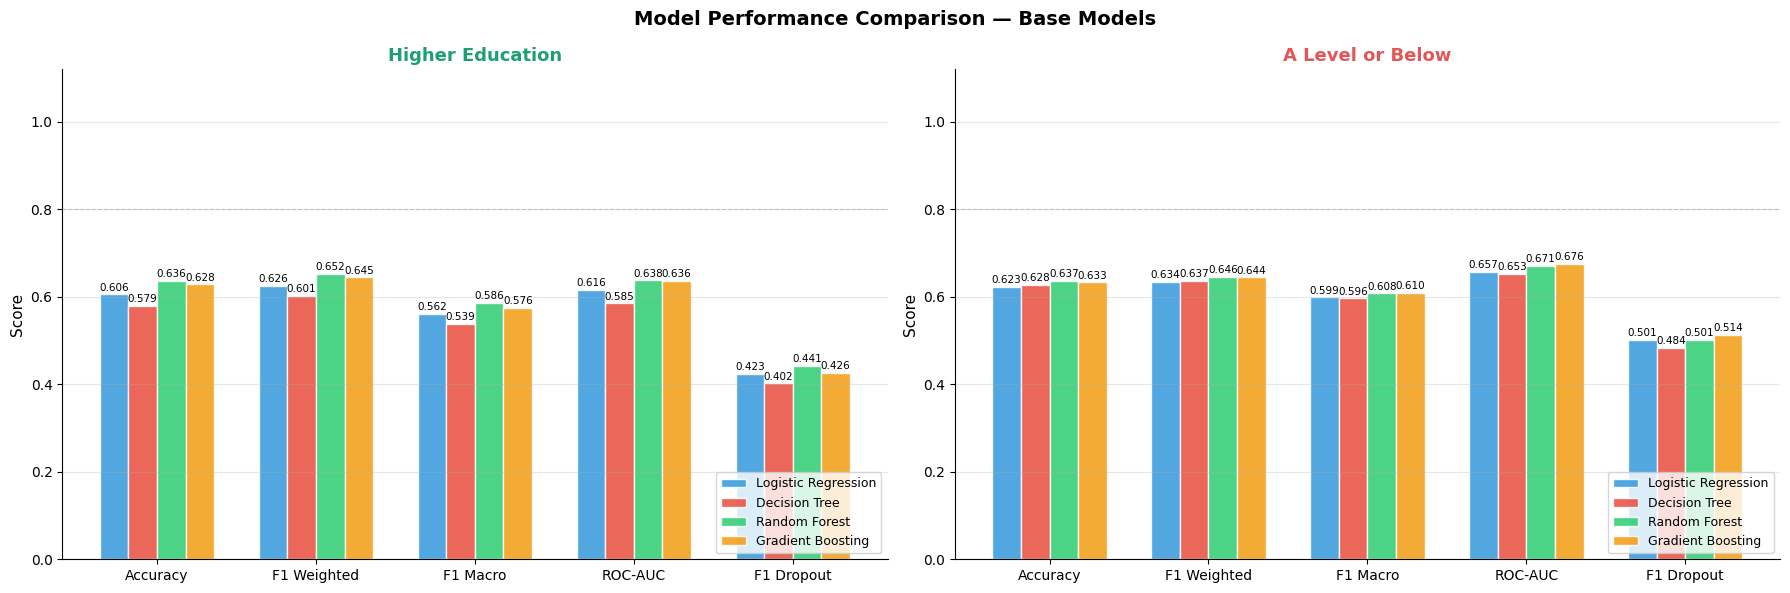

Saved: plot_metrics_he_al.png


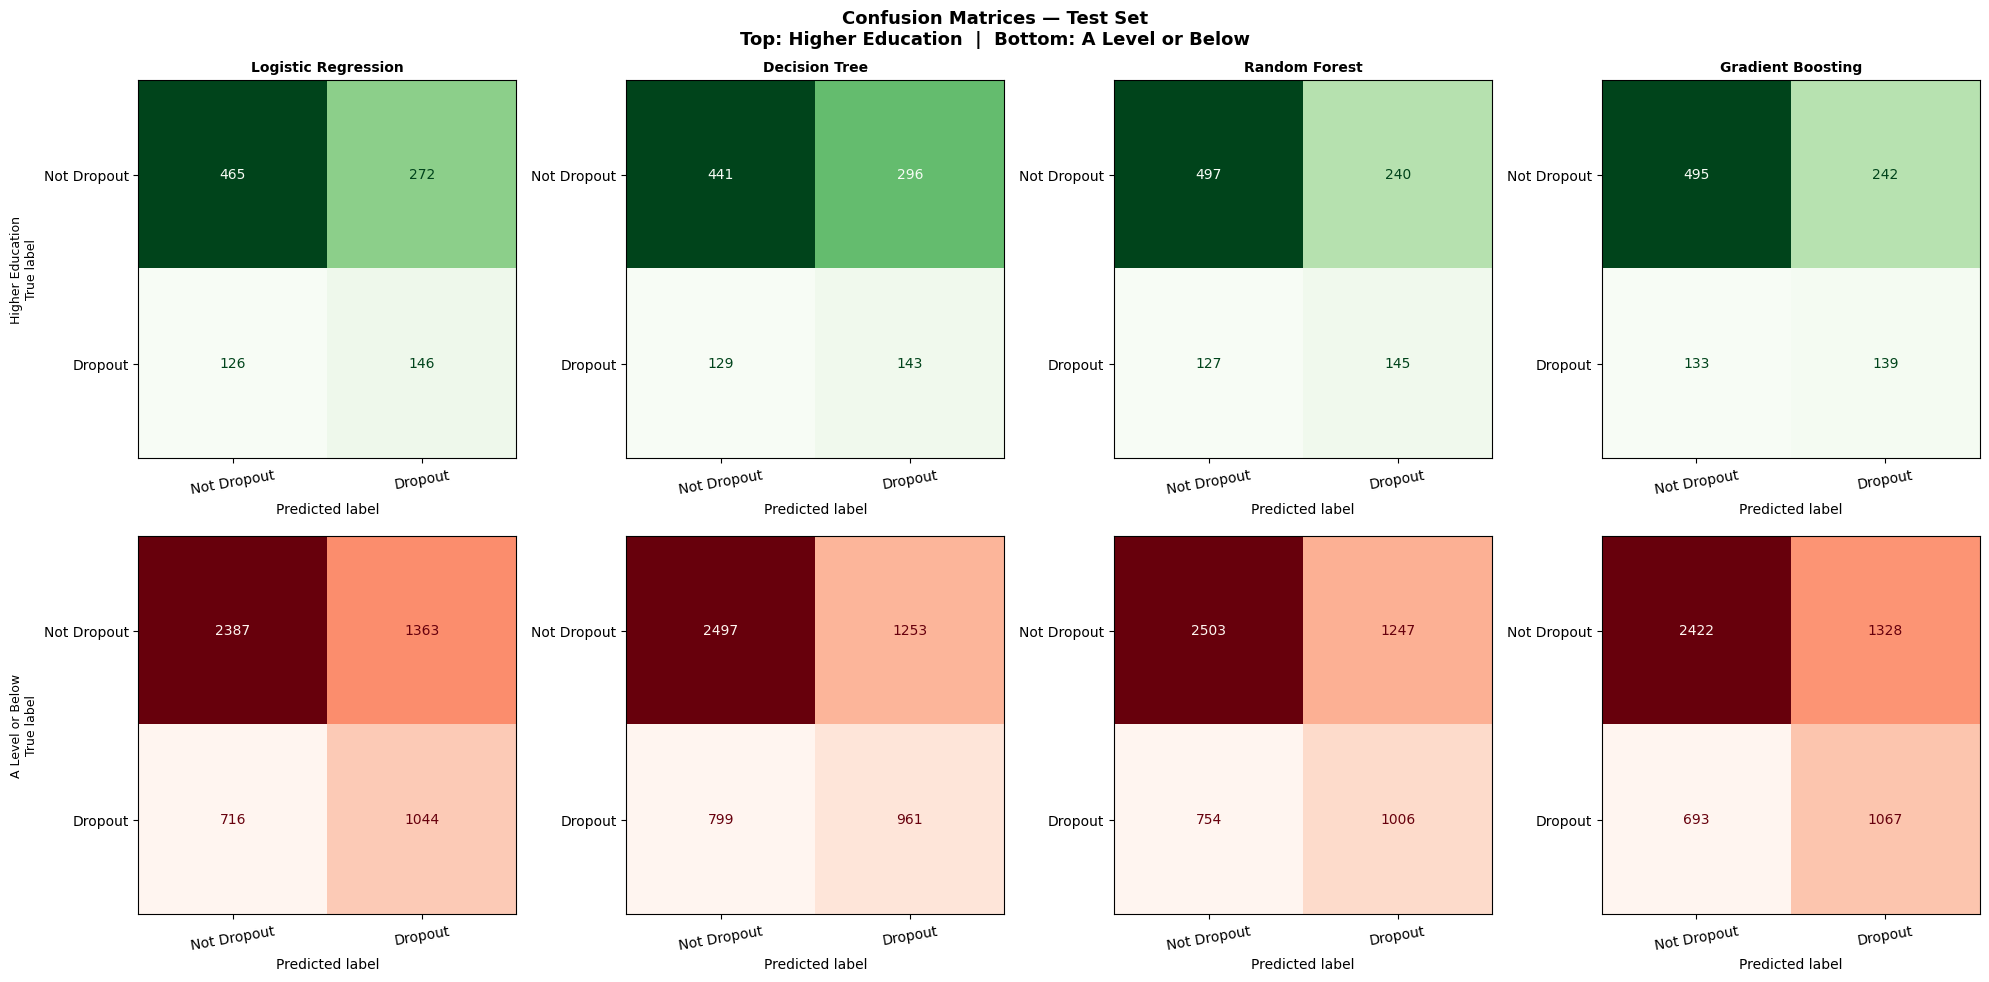

Saved: plot_confusion_he_al.png


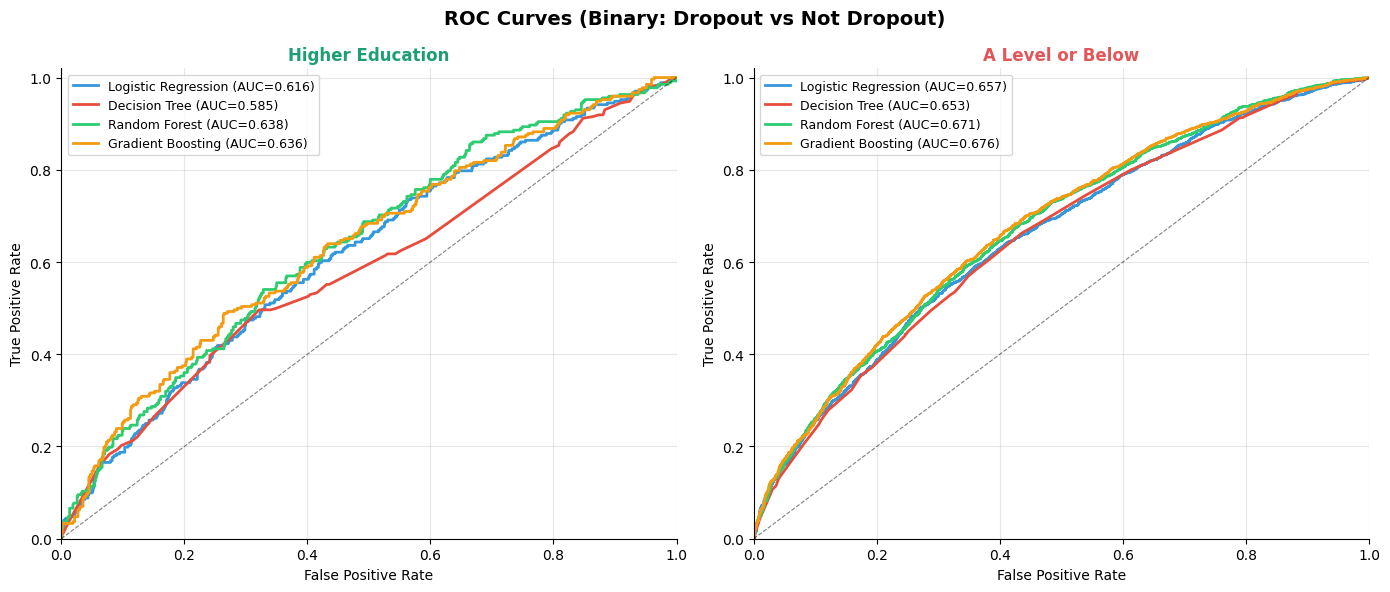

Saved: plot_roc_he_al.png


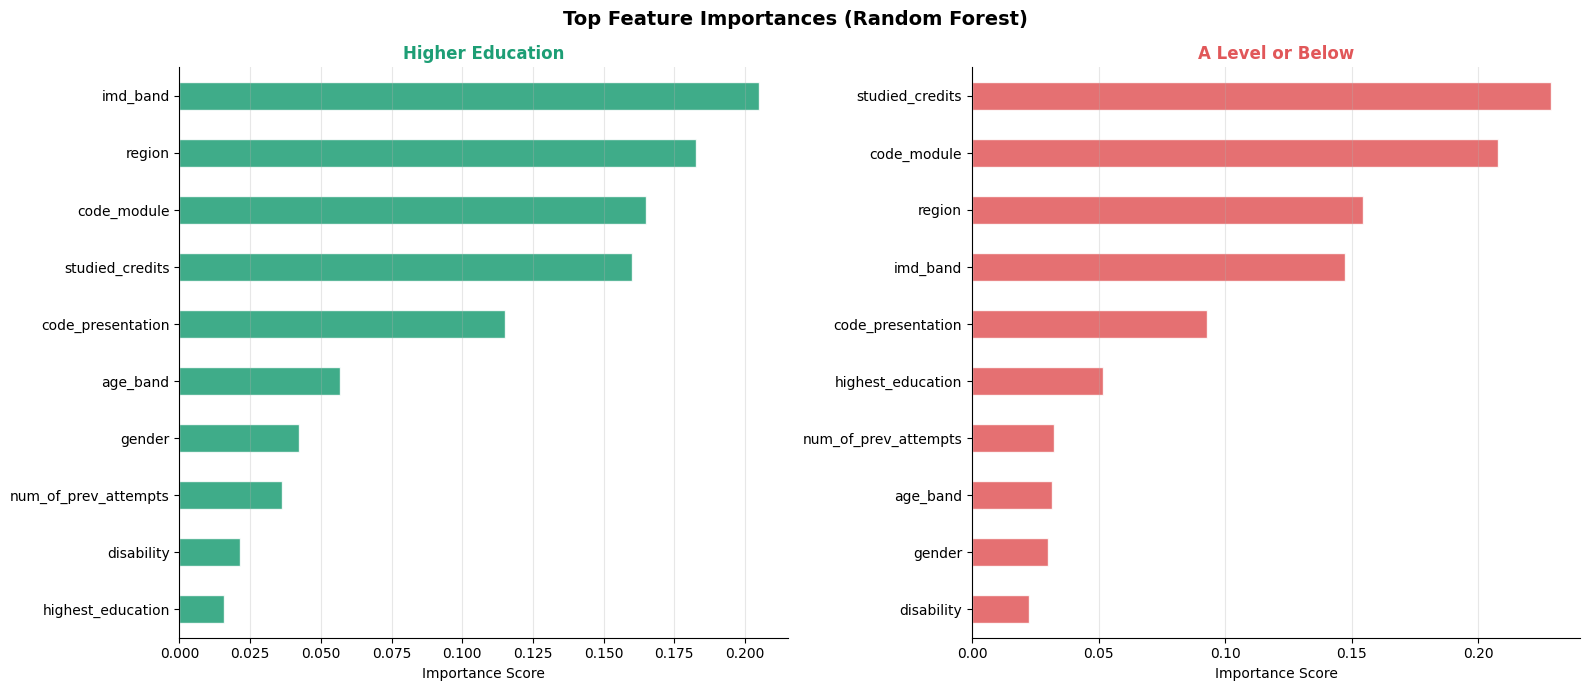

Saved: plot_importance_he_al.png


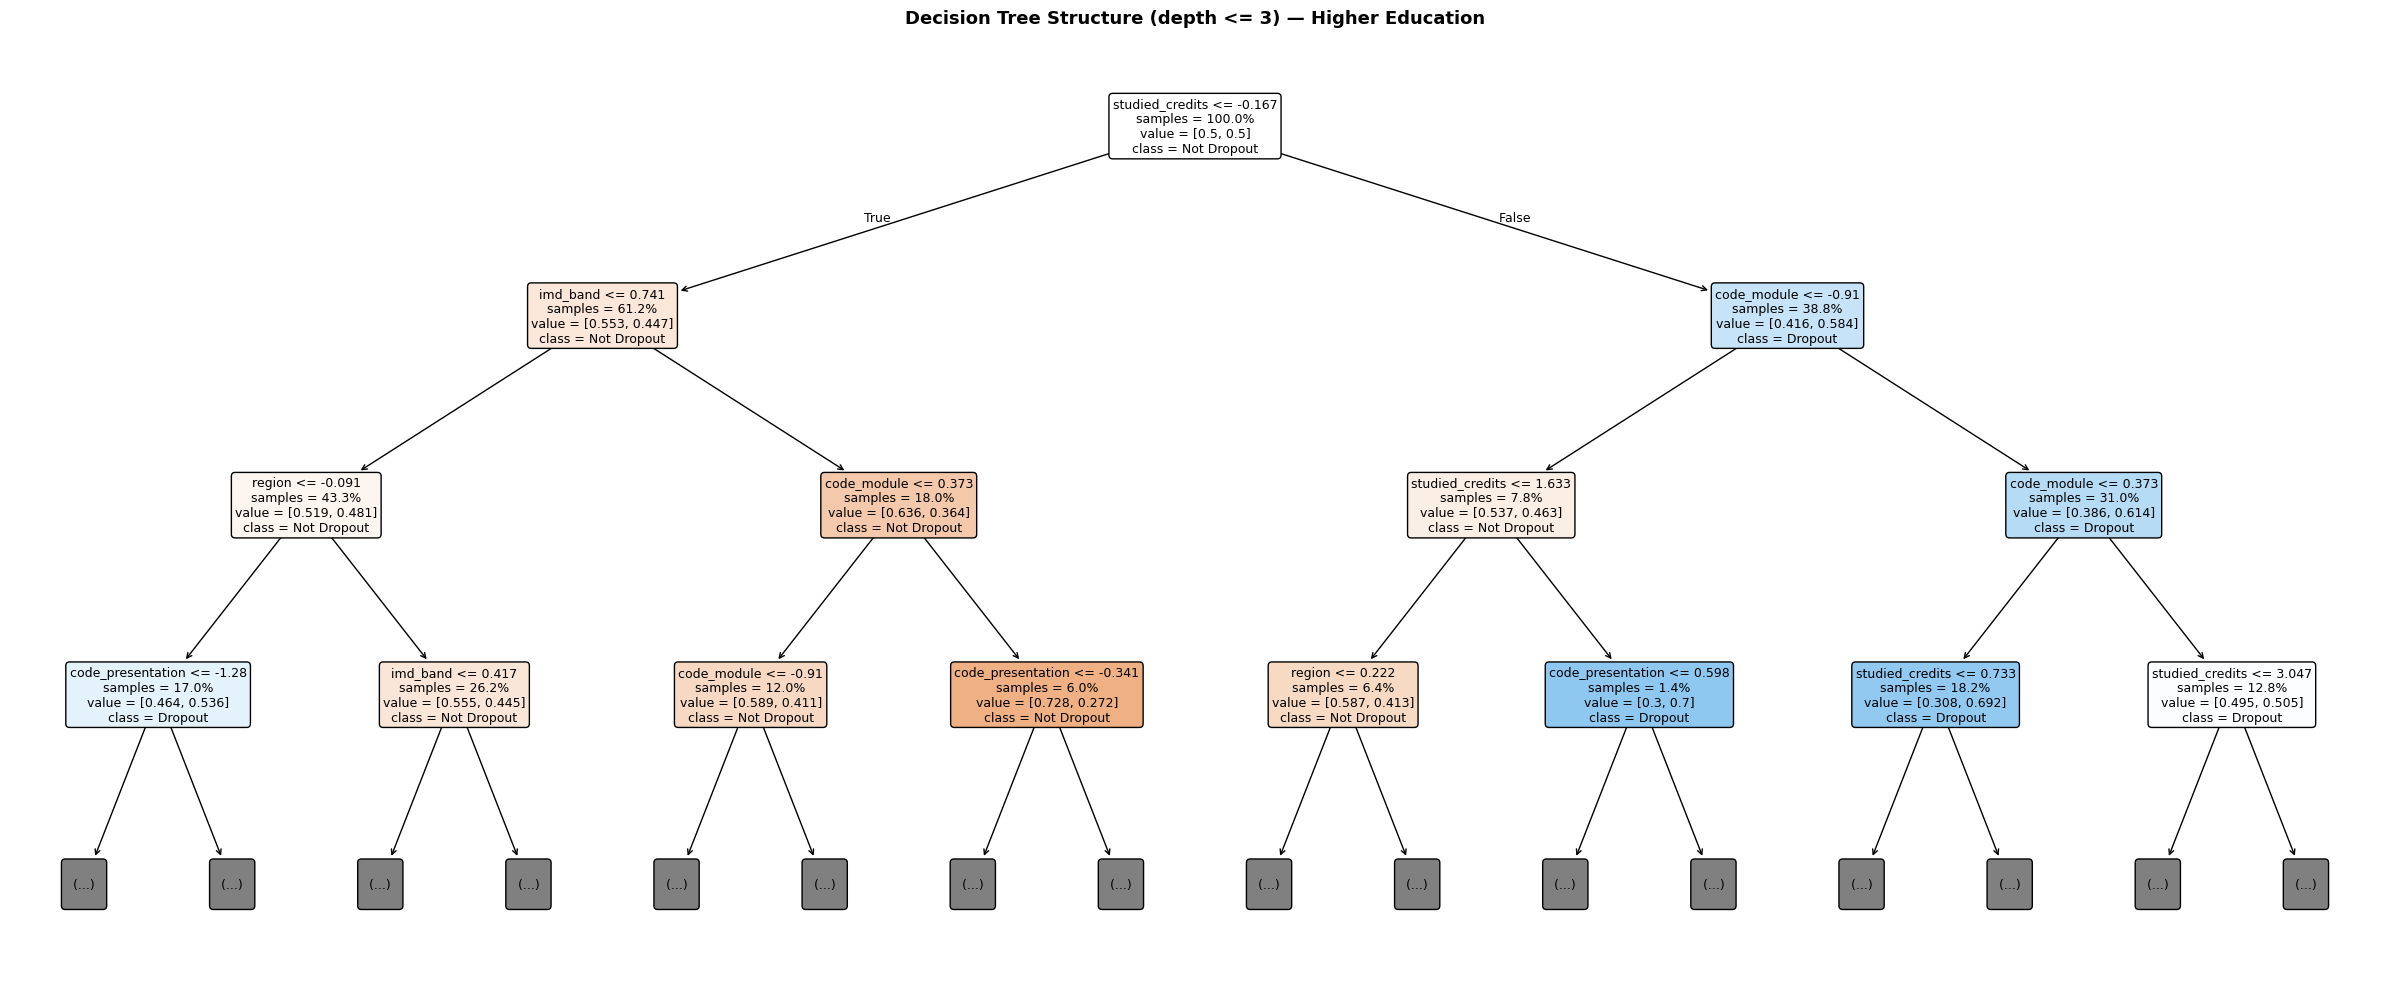

Saved: plot_tree_he.png


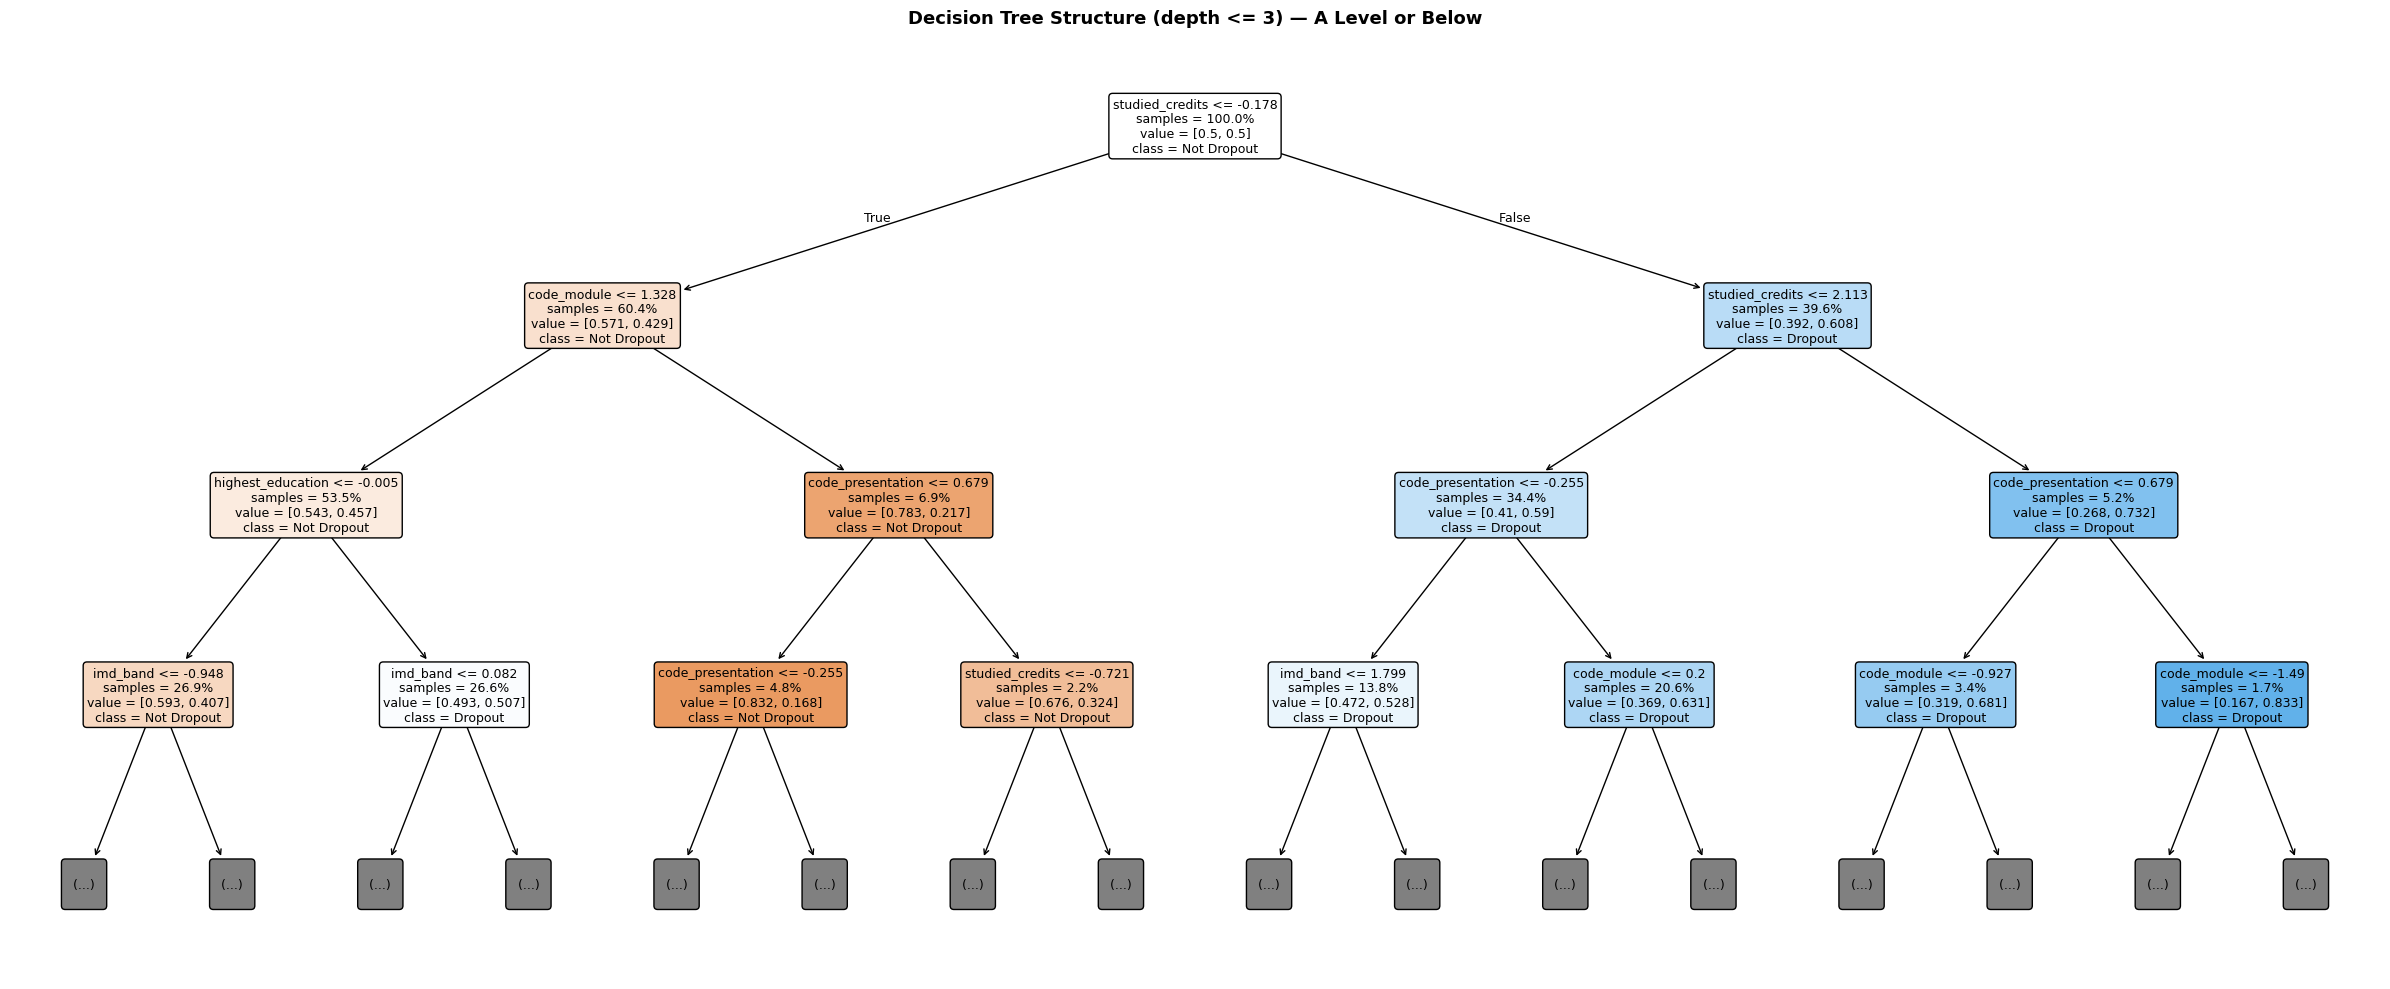

Saved: plot_tree_al.png


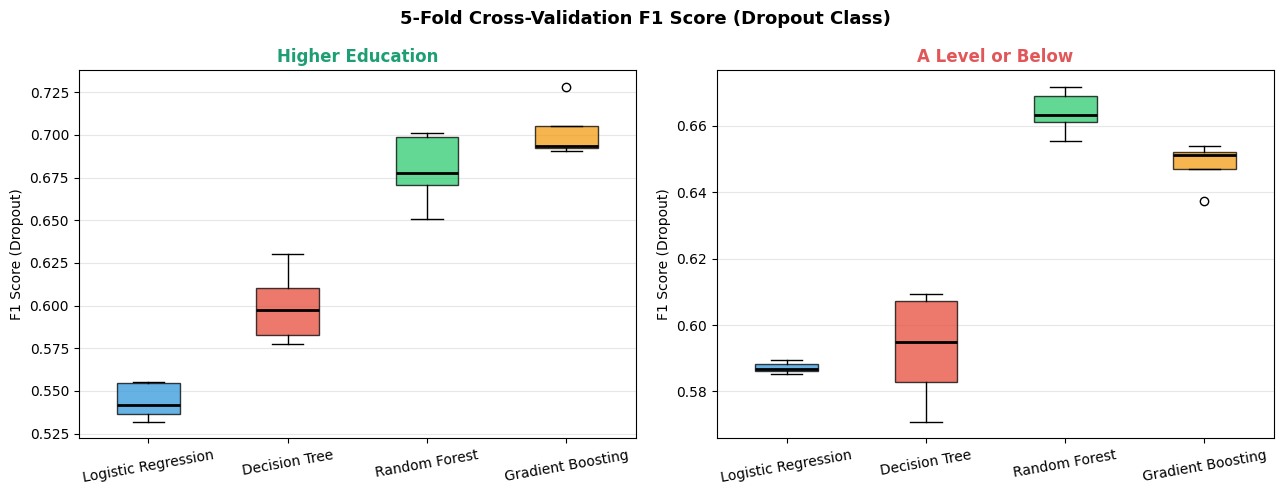

Saved: plot_cv_boxplot_he_al.png


In [8]:
section('STEP 6 — PLOTS (base models)')

palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# 6a. Metrics comparison — one panel per group
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Performance Comparison — Base Models', fontsize=14, fontweight='bold')

metrics_to_plot = ['Accuracy', 'F1_Weighted', 'F1_Macro', 'ROC_AUC', 'F1_Dropout']
metric_labels   = ['Accuracy', 'F1 Weighted', 'F1 Macro', 'ROC-AUC', 'F1 Dropout']
x = np.arange(len(metrics_to_plot)); width = 0.18

for ax, gname, gc in zip(axes, GROUP_NAMES, GROUP_COLORS):
    for i, (name, color) in enumerate(zip(model_names, palette)):
        vals = [group_data[gname]['results'][name][m] for m in metrics_to_plot]
        bars = ax.bar(x + i*width, vals, width,
                      label=name, color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.set_ylim(0, 1.12); ax.set_ylabel('Score', fontsize=11)
    ax.set_title(gname, fontsize=13, fontweight='bold', color=gc)
    ax.legend(loc='lower right', fontsize=9)
    ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)
    [ax.spines[s].set_visible(False) for s in ['top', 'right']]

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_metrics_he_al.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_metrics_he_al.png')

# 6b. Confusion matrices — 2 rows (groups) × 4 columns (models)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Confusion Matrices — Test Set\nTop: Higher Education  |  Bottom: A Level or Below',
             fontsize=13, fontweight='bold')
cmaps = {'Higher Education': 'Greens', 'A Level or Below': 'Reds'}
for row_i, gname in enumerate(GROUP_NAMES):
    for col_i, name in enumerate(model_names):
        ax = axes[row_i][col_i]
        cm = confusion_matrix(group_data[gname]['y_test'],
                              group_data[gname]['results'][name]['y_pred'])
        ConfusionMatrixDisplay(cm, display_labels=['Not Dropout', 'Dropout']).plot(
            ax=ax, colorbar=False, cmap=cmaps[gname])
        ax.set_title(name if row_i == 0 else '', fontweight='bold', fontsize=10)
        ax.tick_params(axis='x', rotation=10)
        if col_i == 0:
            ax.set_ylabel(f'{gname}\nTrue label', fontsize=9)
        else:
            ax.set_ylabel('')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_confusion_he_al.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_confusion_he_al.png')

# 6c. ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves (Binary: Dropout vs Not Dropout)', fontsize=14, fontweight='bold')
for ax, gname, gc in zip(axes, GROUP_NAMES, GROUP_COLORS):
    for name, color in zip(model_names, palette):
        res = group_data[gname]['results'][name]
        fpr, tpr, _ = roc_curve(group_data[gname]['y_test'], res['y_prob'])
        ax.plot(fpr, tpr, label=f'{name} (AUC={res["ROC_AUC"]:.3f})',
                color=color, linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(gname, fontweight='bold', fontsize=12, color=gc)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    [ax.spines[s].set_visible(False) for s in ['top', 'right']]

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_roc_he_al.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_roc_he_al.png')

# 6d. Feature importances (Random Forest)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
for ax, gname, gc in zip(axes, GROUP_NAMES, GROUP_COLORS):
    X_cols = group_data[gname]['X'].columns
    imp = pd.Series(
        group_data[gname]['trained_models']['Random Forest'].feature_importances_,
        index=X_cols).nlargest(10)
    imp.sort_values().plot(kind='barh', ax=ax, color=gc, alpha=0.85, edgecolor='white')
    ax.set_title(gname, fontweight='bold', fontsize=12, color=gc)
    ax.set_xlabel('Importance Score'); ax.grid(axis='x', alpha=0.3)
    [ax.spines[s].set_visible(False) for s in ['top', 'right']]

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_importance_he_al.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_importance_he_al.png')

# 6e. Decision Tree visualisation — one per group
for gname in GROUP_NAMES:
    fig, ax = plt.subplots(figsize=(24, 10))
    plot_tree(
        group_data[gname]['trained_models']['Decision Tree'],
        feature_names=group_data[gname]['X'].columns.tolist(),
        class_names=['Not Dropout', 'Dropout'],
        filled=True, rounded=True, max_depth=3,
        fontsize=9, ax=ax, impurity=False, proportion=True)
    ax.set_title(f'Decision Tree Structure (depth <= 3) — {gname}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = 'plot_tree_he.png' if gname == 'Higher Education' else 'plot_tree_al.png'
    plt.savefig(f'{OUTPUT_DIR}/{fname}', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

# 6f. CV boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('5-Fold Cross-Validation F1 Score (Dropout Class)', fontsize=13, fontweight='bold')
for ax, gname, gc in zip(axes, GROUP_NAMES, GROUP_COLORS):
    cv_data = [group_data[gname]['cv_scores'][n] for n in model_names]
    bp = ax.boxplot(cv_data, labels=model_names, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title(gname, fontsize=12, fontweight='bold', color=gc)
    ax.set_ylabel('F1 Score (Dropout)'); ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_cv_boxplot_he_al.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_cv_boxplot_he_al.png')

# ─────────────────────────────────────────────────────────────────────────────
# 7.  ENSEMBLE METHODS  (Voting + Stacking)
# ─────────────────────────────────────────────────────────────────────────────


  STEP 7 — ENSEMBLE METHODS (Voting + Stacking)

  GROUP: Higher Education

[A] Soft Voting Ensemble (RF + GB)...
  Accuracy     : 0.6293
  F1 Weighted  : 0.6457
  ROC-AUC      : 0.6424
  F1 (Dropout) : 0.4299

[B] Stacking Ensemble (RF + GB → LR meta-learner)...
  Accuracy     : 0.6363
  F1 Weighted  : 0.6512
  ROC-AUC      : 0.6389
  F1 (Dropout) : 0.4292

              precision    recall  f1-score   support

 Not Dropout     0.7900    0.6839    0.7331       737
     Dropout     0.3720    0.5074    0.4292       272

    accuracy                         0.6363      1009
   macro avg     0.5810    0.5956    0.5812      1009
weighted avg     0.6773    0.6363    0.6512      1009


  GROUP: A Level or Below

[A] Soft Voting Ensemble (RF + GB)...
  Accuracy     : 0.6387
  F1 Weighted  : 0.6488
  ROC-AUC      : 0.6766
  F1 (Dropout) : 0.5117

[B] Stacking Ensemble (RF + GB → LR meta-learner)...
  Accuracy     : 0.6374
  F1 Weighted  : 0.6469
  ROC-AUC      : 0.6719
  F1 (Dropout) : 0.5022

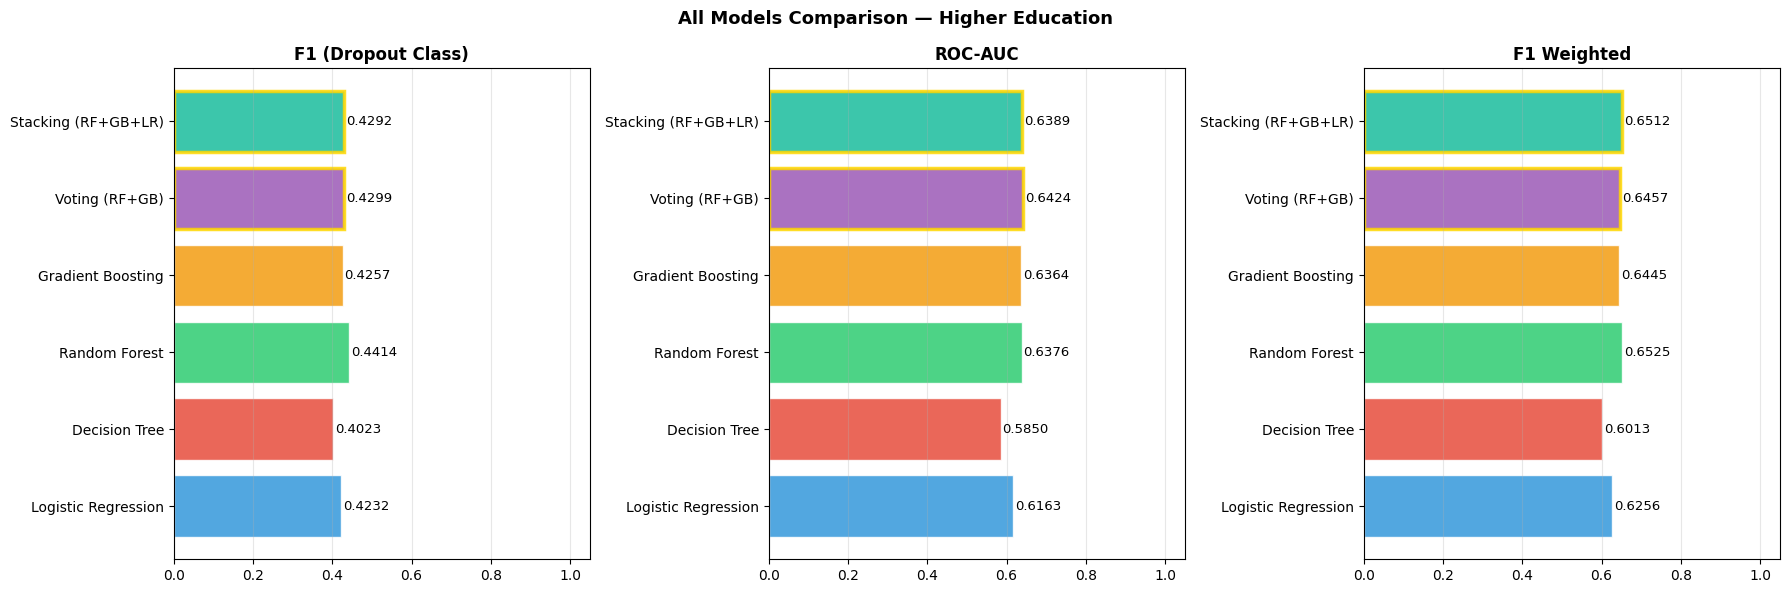

Saved: plot_ensemble_he.png


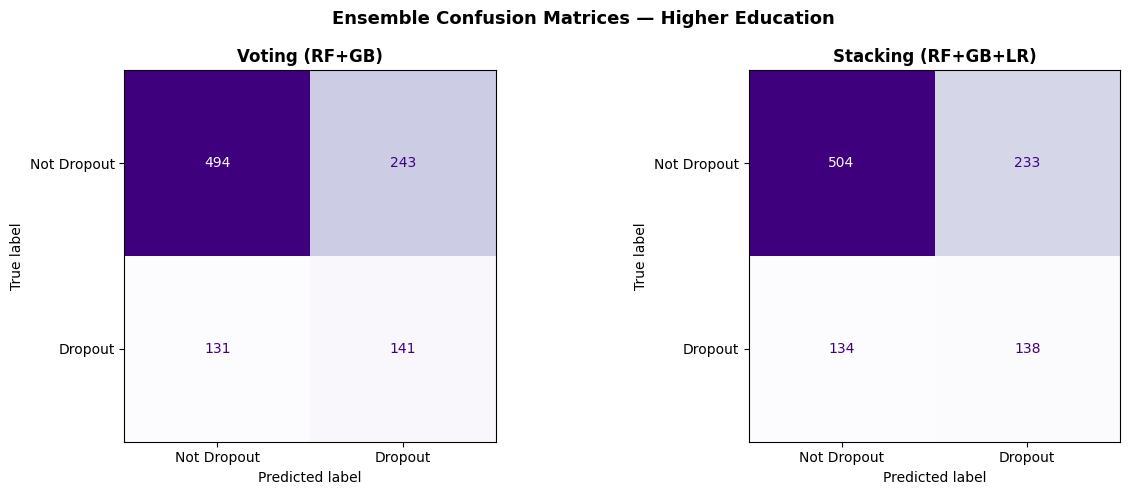

Saved: plot_ensemble_cm_he.png


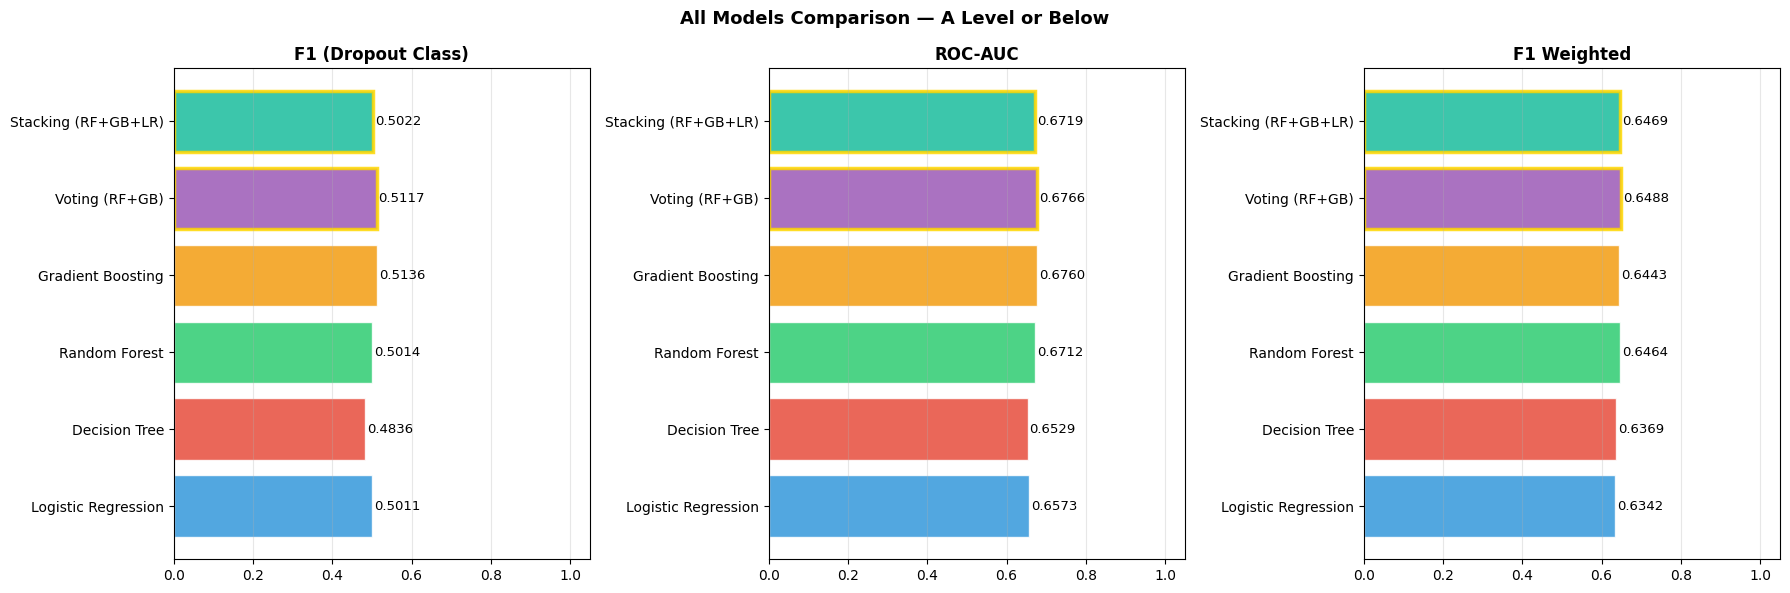

Saved: plot_ensemble_al.png


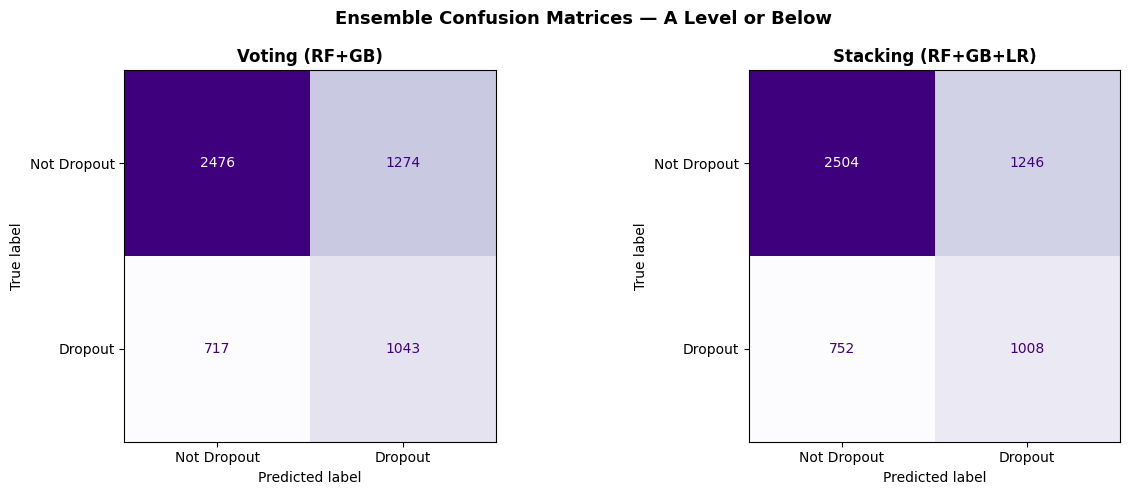

Saved: plot_ensemble_cm_al.png


In [9]:
section('STEP 7 — ENSEMBLE METHODS (Voting + Stacking)')

for gname in GROUP_NAMES:
    print(f'\n{"="*60}')
    print(f'  GROUP: {gname}')
    print(f'{"="*60}')

    gd = group_data[gname]

    # 7a. Soft Voting (RF + GB)
    print('\n[A] Soft Voting Ensemble (RF + GB)...')
    voting_clf = VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                n_estimators=200, max_depth=12, min_samples_leaf=10,
                class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED)),
            ('gb', GradientBoostingClassifier(
                n_estimators=200, max_depth=5, learning_rate=0.05,
                subsample=0.8, random_state=RANDOM_SEED)),
        ], voting='soft')
    voting_clf.fit(gd['X_train_bal'], gd['y_train_bal'])

    y_pred_vote = voting_clf.predict(gd['X_test'])
    y_prob_vote = voting_clf.predict_proba(gd['X_test'])[:, 1]
    roc_vote    = roc_auc_score(gd['y_test'], y_prob_vote)
    f1d_vote    = f1_score(gd['y_test'], y_pred_vote)
    print(f'  Accuracy     : {accuracy_score(gd["y_test"], y_pred_vote):.4f}')
    print(f'  F1 Weighted  : {f1_score(gd["y_test"], y_pred_vote, average="weighted"):.4f}')
    print(f'  ROC-AUC      : {roc_vote:.4f}')
    print(f'  F1 (Dropout) : {f1d_vote:.4f}')

    # 7b. Stacking (RF + GB → LR meta-learner)
    print('\n[B] Stacking Ensemble (RF + GB → LR meta-learner)...')
    stacking_clf = StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                n_estimators=200, max_depth=12, min_samples_leaf=10,
                class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED)),
            ('gb', GradientBoostingClassifier(
                n_estimators=200, max_depth=5, learning_rate=0.05,
                subsample=0.8, random_state=RANDOM_SEED)),
        ],
        final_estimator=LogisticRegression(
            max_iter=1000, C=1.0,
            class_weight='balanced', random_state=RANDOM_SEED),
        cv=5, passthrough=False, n_jobs=-1)
    stacking_clf.fit(gd['X_train_bal'], gd['y_train_bal'])

    y_pred_stack = stacking_clf.predict(gd['X_test'])
    y_prob_stack = stacking_clf.predict_proba(gd['X_test'])[:, 1]
    roc_stack    = roc_auc_score(gd['y_test'], y_prob_stack)
    f1d_stack    = f1_score(gd['y_test'], y_pred_stack)
    print(f'  Accuracy     : {accuracy_score(gd["y_test"], y_pred_stack):.4f}')
    print(f'  F1 Weighted  : {f1_score(gd["y_test"], y_pred_stack, average="weighted"):.4f}')
    print(f'  ROC-AUC      : {roc_stack:.4f}')
    print(f'  F1 (Dropout) : {f1d_stack:.4f}')
    print()
    print(classification_report(gd['y_test'], y_pred_stack,
                                 target_names=['Not Dropout', 'Dropout'], digits=4))

    group_data[gname].update(dict(
        y_pred_vote=y_pred_vote, y_prob_vote=y_prob_vote,
        roc_vote=roc_vote, f1d_vote=f1d_vote,
        y_pred_stack=y_pred_stack, y_prob_stack=y_prob_stack,
        roc_stack=roc_stack, f1d_stack=f1d_stack,
    ))

# Ensemble plots
for gname, gc in zip(GROUP_NAMES, GROUP_COLORS):
    gd = group_data[gname]
    suffix = 'he' if gname == 'Higher Education' else 'al'

    all_names  = model_names + ['Voting (RF+GB)', 'Stacking (RF+GB+LR)']
    all_f1d    = ([gd['results'][n]['F1_Dropout'] for n in model_names] +
                  [gd['f1d_vote'], gd['f1d_stack']])
    all_roc    = ([gd['results'][n]['ROC_AUC']    for n in model_names] +
                  [gd['roc_vote'], gd['roc_stack']])
    all_f1w    = ([gd['results'][n]['F1_Weighted'] for n in model_names] +
                  [f1_score(gd['y_test'], gd['y_pred_vote'], average='weighted'),
                   f1_score(gd['y_test'], gd['y_pred_stack'], average='weighted')])
    all_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'All Models Comparison — {gname}', fontsize=13, fontweight='bold')
    for ax, (title, vals) in zip(axes, [
        ('F1 (Dropout Class)', all_f1d),
        ('ROC-AUC',            all_roc),
        ('F1 Weighted',        all_f1w)
    ]):
        bars = ax.barh(all_names, vals, color=all_colors, alpha=0.85, edgecolor='white')
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlim(0, 1.05)
        for bar, val in zip(bars, vals):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=9.5)
        ax.grid(axis='x', alpha=0.3)
    for ax in axes:
        for patch in ax.patches[-2:]:
            patch.set_edgecolor('gold'); patch.set_linewidth(2.5)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/plot_ensemble_{suffix}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: plot_ensemble_{suffix}.png')

    # Ensemble confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Ensemble Confusion Matrices — {gname}', fontsize=13, fontweight='bold')
    for ax, (ename, yp) in zip(axes, [
        ('Voting (RF+GB)',       gd['y_pred_vote']),
        ('Stacking (RF+GB+LR)', gd['y_pred_stack'])
    ]):
        ConfusionMatrixDisplay(
            confusion_matrix(gd['y_test'], yp),
            display_labels=['Not Dropout', 'Dropout']
        ).plot(ax=ax, colorbar=False, cmap='Purples')
        ax.set_title(ename, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/plot_ensemble_cm_{suffix}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: plot_ensemble_cm_{suffix}.png')

# ─────────────────────────────────────────────────────────────────────────────
# 8.  BINARY CLASSIFIER — Dropout vs Non-Dropout
# ─────────────────────────────────────────────────────────────────────────────


  STEP 8 — BINARY CLASSIFIER (Dropout vs Non-Dropout)

Higher Education
  ROC-AUC (binary)  : 0.6419
  F1 (Dropout class): 0.4340
  Accuracy          : 0.6432

              precision    recall  f1-score   support

 Not Dropout     0.7922    0.6934    0.7395       737
     Dropout     0.3791    0.5074    0.4340       272

    accuracy                         0.6432      1009
   macro avg     0.5857    0.6004    0.5867      1009
weighted avg     0.6809    0.6432    0.6571      1009


A Level or Below
  ROC-AUC (binary)  : 0.6737
  F1 (Dropout class): 0.5076
  Accuracy          : 0.6437

              precision    recall  f1-score   support

 Not Dropout     0.7722    0.6760    0.7209      3750
     Dropout     0.4544    0.5750    0.5076      1760

    accuracy                         0.6437      5510
   macro avg     0.6133    0.6255    0.6143      5510
weighted avg     0.6707    0.6437    0.6528      5510



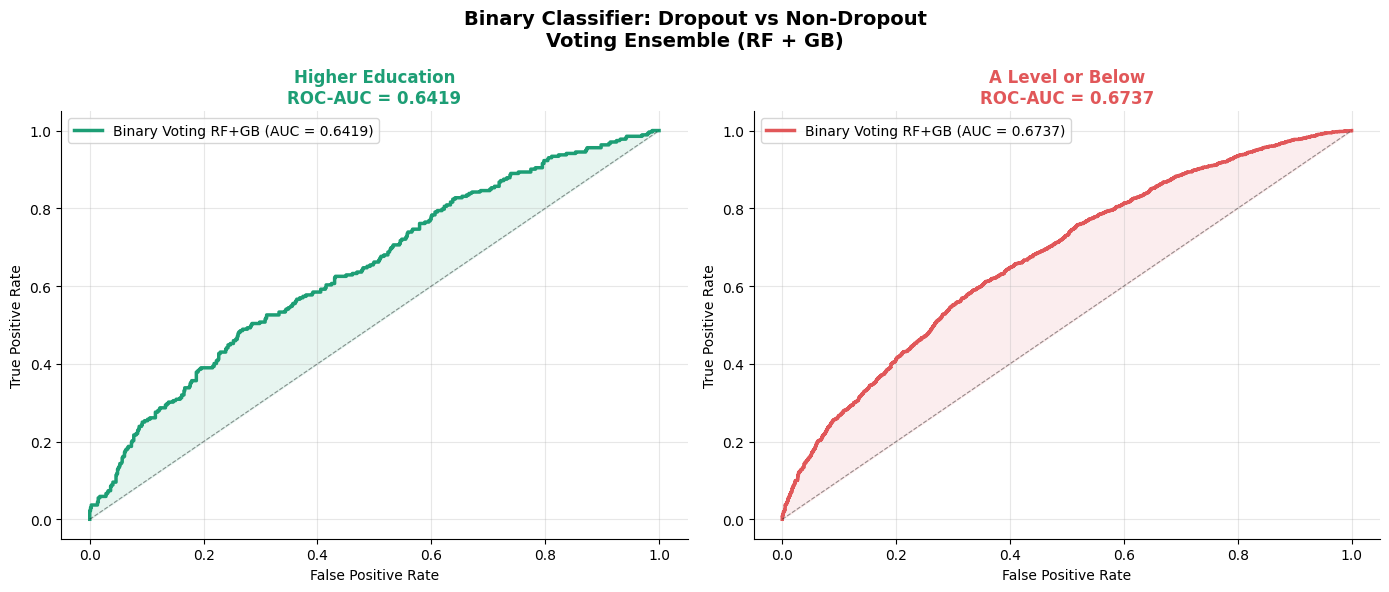

Saved: plot_binary_roc_he_al.png


In [10]:
section('STEP 8 — BINARY CLASSIFIER (Dropout vs Non-Dropout)')

"""
WHY BINARY?
The studentInfo dataset already has a binary target (dropout=1 / not=0).
This step trains a dedicated high-performance Voting RF+GB classifier
on each group with deeper trees, then shows the ROC curve.
This is the most actionable model for an early-warning system.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Binary Classifier: Dropout vs Non-Dropout\nVoting Ensemble (RF + GB)',
             fontsize=14, fontweight='bold')

for ax, gname, gc in zip(axes, GROUP_NAMES, GROUP_COLORS):
    gd = group_data[gname]

    bin_rf   = RandomForestClassifier(
        n_estimators=300, max_depth=14, min_samples_leaf=5,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED)
    bin_gb   = GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_SEED)
    bin_vote = VotingClassifier([('rf', bin_rf), ('gb', bin_gb)], voting='soft')
    bin_vote.fit(gd['X_train_bal'], gd['y_train_bal'])

    prob_bin = bin_vote.predict_proba(gd['X_test'])[:, 1]
    pred_bin = bin_vote.predict(gd['X_test'])

    roc_bin = roc_auc_score(gd['y_test'], prob_bin)
    f1_bin  = f1_score(gd['y_test'], pred_bin)
    acc_bin = accuracy_score(gd['y_test'], pred_bin)

    print(f'\n{gname}')
    print(f'  ROC-AUC (binary)  : {roc_bin:.4f}')
    print(f'  F1 (Dropout class): {f1_bin:.4f}')
    print(f'  Accuracy          : {acc_bin:.4f}')
    print()
    print(classification_report(gd['y_test'], pred_bin,
                                 target_names=['Not Dropout', 'Dropout'], digits=4))

    group_data[gname].update(dict(
        roc_bin=roc_bin, f1_bin=f1_bin, acc_bin=acc_bin, pred_bin=pred_bin))

    fpr_b, tpr_b, _ = roc_curve(gd['y_test'], prob_bin)
    ax.plot(fpr_b, tpr_b, color=gc, linewidth=2.5,
            label=f'Binary Voting RF+GB (AUC = {roc_bin:.4f})')
    ax.fill_between(fpr_b, fpr_b, tpr_b, alpha=0.10, color=gc)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=0.8)
    ax.set_title(f'{gname}\nROC-AUC = {roc_bin:.4f}', fontsize=12, fontweight='bold', color=gc)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    [ax.spines[s].set_visible(False) for s in ['top', 'right']]

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_binary_roc_he_al.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_binary_roc_he_al.png')

# ─────────────────────────────────────────────────────────────────────────────
# 9.  FULL 10-FOLD CROSS-VALIDATION  (uses 100% of data)
# ─────────────────────────────────────────────────────────────────────────────


  STEP 9 — FULL 10-FOLD CROSS-VALIDATION (all students per group)

  GROUP: Higher Education  — running 10-fold CV (scaling inside each fold)...

  Logistic Regression
    Test  ROC-AUC : 0.6066 ± 0.0278
    Train ROC-AUC : 0.6130 ± 0.0054
    Test  F1      : 0.4168 ± 0.0276
    Gap           : 0.0064  (well generalised)

  Random Forest
    Test  ROC-AUC : 0.6379 ± 0.0222
    Train ROC-AUC : 0.8408 ± 0.0019
    Test  F1      : 0.4373 ± 0.0314
    Gap           : 0.2028  (overfitting)

  Gradient Boosting
    Test  ROC-AUC : 0.6243 ± 0.0254
    Train ROC-AUC : 0.8355 ± 0.0049
    Test  F1      : 0.4290 ± 0.0219
    Gap           : 0.2112  (overfitting)


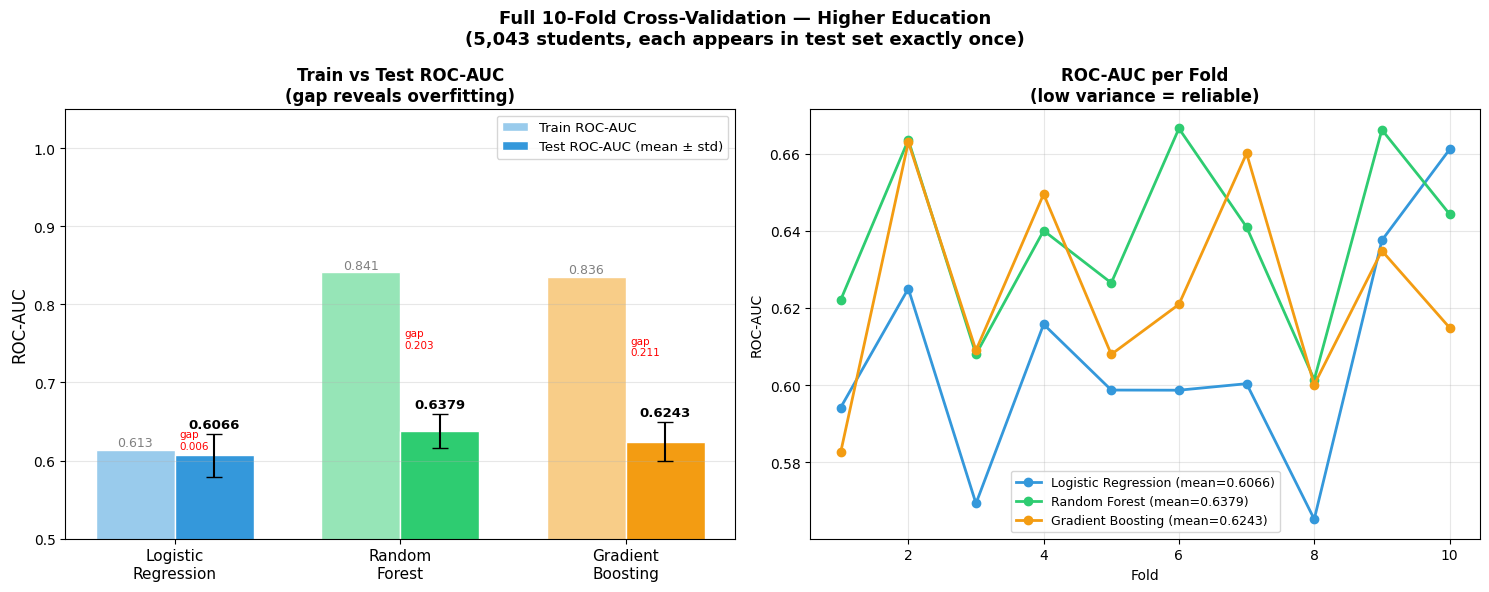

Saved: plot_full_cv_he.png

  GROUP: A Level or Below  — running 10-fold CV (scaling inside each fold)...

  Logistic Regression
    Test  ROC-AUC : 0.6471 ± 0.0140
    Train ROC-AUC : 0.6479 ± 0.0025
    Test  F1      : 0.4876 ± 0.0132
    Gap           : 0.0008  (well generalised)

  Random Forest
    Test  ROC-AUC : 0.6690 ± 0.0136
    Train ROC-AUC : 0.7805 ± 0.0011
    Test  F1      : 0.4995 ± 0.0132
    Gap           : 0.1116  (overfitting)

  Gradient Boosting
    Test  ROC-AUC : 0.6742 ± 0.0136
    Train ROC-AUC : 0.7282 ± 0.0016
    Test  F1      : 0.5094 ± 0.0146
    Gap           : 0.0541  (slight overfitting)


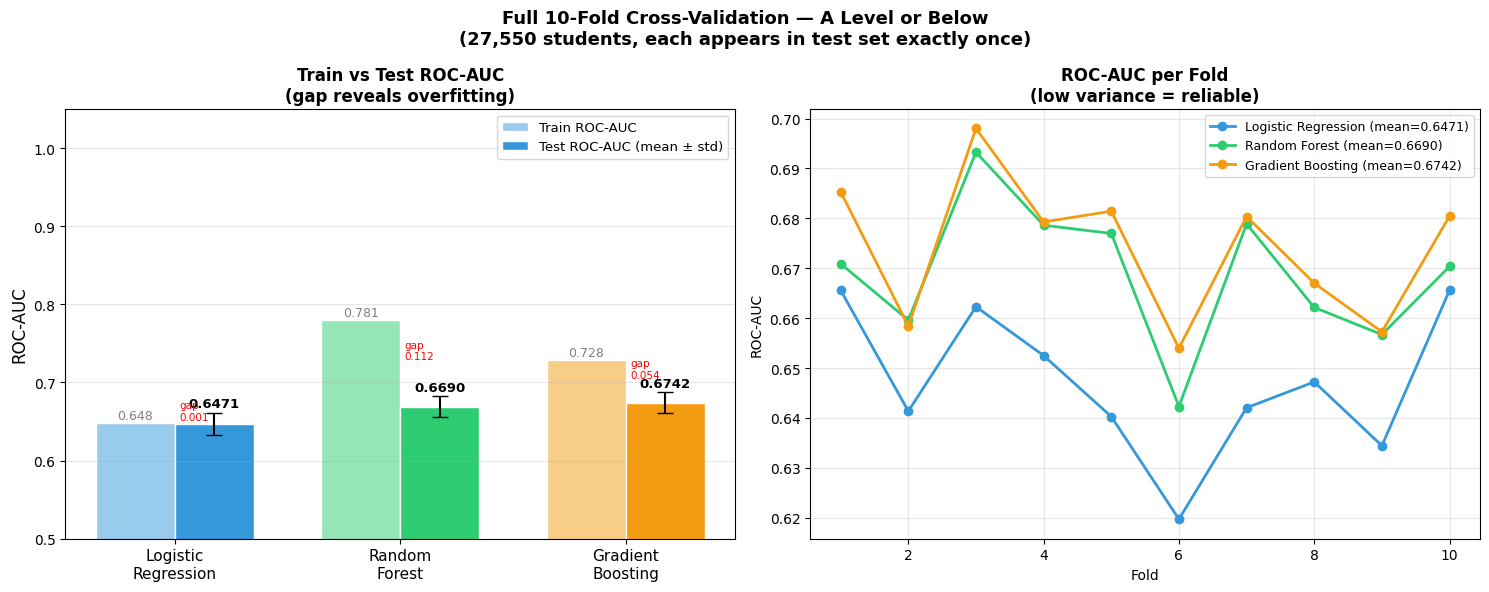

Saved: plot_full_cv_al.png


In [11]:
section('STEP 9 — FULL 10-FOLD CROSS-VALIDATION (all students per group)')

"""
HOW FULL CV WORKS
─────────────────────────────────────────────────────────────
Each group split into 10 equal folds.
Each iteration:  9 folds → train   |   1 fold → test
After 10 iterations every student has been in the test set
exactly once.  No student is ever excluded.

Key advantage over 80/20 split:
  • All data used for both training and evaluation
  • 10 independent test scores → robust mean + standard deviation
  • Reveals overfitting: large train-test gap = model memorising not learning
─────────────────────────────────────────────────────────────
"""

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
cv_model_fns = {
    'Logistic Regression': lambda: LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_SEED),
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED),
    'Gradient Boosting': lambda: GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=RANDOM_SEED),
}
cv_model_names = list(cv_model_fns.keys())
cv_palette     = ['#3498db', '#2ecc71', '#f39c12']

for gname in GROUP_NAMES:
    print(f'\n{"="*60}')
    print(f'  GROUP: {gname}  — running 10-fold CV (scaling inside each fold)...')
    print(f'{"="*60}')

    gd    = group_data[gname]
    X_raw = gd['X'].values
    y_all = gd['y']
    full_cv = {}

    for name, model_fn in cv_model_fns.items():
        fold_roc_te, fold_roc_tr, fold_f1 = [], [], []

        for tr_idx, te_idx in cv10.split(X_raw, y_all):
            X_tr_f, X_te_f = X_raw[tr_idx], X_raw[te_idx]
            y_tr_f = y_all.iloc[tr_idx]
            y_te_f = y_all.iloc[te_idx]

            df_fold = pd.DataFrame(X_tr_f)
            df_fold['__l__'] = y_tr_f.values
            mc  = df_fold['__l__'].value_counts().idxmax()
            mn  = df_fold['__l__'].value_counts().max()
            parts = [
                resample(df_fold[df_fold['__l__'] == c],
                         replace=True, n_samples=mn, random_state=RANDOM_SEED)
                if c != mc else df_fold[df_fold['__l__'] == mc]
                for c in df_fold['__l__'].unique()
            ]
            bal  = pd.concat(parts).sample(frac=1, random_state=RANDOM_SEED)
            Xb_f = bal.drop(columns=['__l__']).values
            yb_f = bal['__l__'].values

            sc_fold = StandardScaler()
            Xb_f    = sc_fold.fit_transform(Xb_f)
            X_te_fs = sc_fold.transform(X_te_f)

            m = model_fn()
            m.fit(Xb_f, yb_f)

            fold_roc_te.append(roc_auc_score(y_te_f, m.predict_proba(X_te_fs)[:, 1]))
            fold_roc_tr.append(roc_auc_score(yb_f,   m.predict_proba(Xb_f)[:, 1]))
            fold_f1.append(f1_score(y_te_f, m.predict(X_te_fs)))

        full_cv[name] = {
            'test_roc' : np.array(fold_roc_te),
            'train_roc': np.array(fold_roc_tr),
            'test_f1'  : np.array(fold_f1),
        }
        gap     = np.mean(fold_roc_tr) - np.mean(fold_roc_te)
        verdict = ('well generalised' if gap < 0.02 else
                   'slight overfitting' if gap < 0.06 else 'overfitting')
        print(f'\n  {name}')
        print(f'    Test  ROC-AUC : {np.mean(fold_roc_te):.4f} ± {np.std(fold_roc_te):.4f}')
        print(f'    Train ROC-AUC : {np.mean(fold_roc_tr):.4f} ± {np.std(fold_roc_tr):.4f}')
        print(f'    Test  F1      : {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}')
        print(f'    Gap           : {gap:.4f}  ({verdict})')

    group_data[gname]['full_cv'] = full_cv

    # Full CV plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    n_total = len(gd['X'])
    fig.suptitle(
        f'Full 10-Fold Cross-Validation — {gname}\n'
        f'({n_total:,} students, each appears in test set exactly once)',
        fontsize=13, fontweight='bold')

    tr_means = [full_cv[n]['train_roc'].mean() for n in cv_model_names]
    te_means = [full_cv[n]['test_roc'].mean()  for n in cv_model_names]
    te_stds  = [full_cv[n]['test_roc'].std()   for n in cv_model_names]
    x = np.arange(len(cv_model_names)); w = 0.35

    axes[0].bar(x - w/2, tr_means, w, label='Train ROC-AUC',
                color=[c + '80' for c in cv_palette], edgecolor='white')
    axes[0].bar(x + w/2, te_means, w, yerr=te_stds,
                label='Test ROC-AUC (mean ± std)',
                color=cv_palette, capsize=6, edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(
        ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting'], fontsize=11)
    axes[0].set_ylim(0.5, 1.05); axes[0].set_ylabel('ROC-AUC', fontsize=12)
    axes[0].set_title('Train vs Test ROC-AUC\n(gap reveals overfitting)', fontweight='bold')
    axes[0].legend(fontsize=9.5); axes[0].grid(axis='y', alpha=0.3)
    for i, (tm, te, ts) in enumerate(zip(tr_means, te_means, te_stds)):
        gap = tm - te
        axes[0].text(i - w/2, tm + 0.005, f'{tm:.3f}', ha='center', fontsize=9, color='gray')
        axes[0].text(i + w/2, te + ts + 0.007, f'{te:.4f}', ha='center', fontsize=9.5, fontweight='bold')
        axes[0].text(i + 0.02, (tm + te)/2 + 0.005,
                     f'gap\n{gap:.3f}', fontsize=7.5, color='red', ha='left')

    for name, color in zip(cv_model_names, cv_palette):
        fold_scores = full_cv[name]['test_roc']
        axes[1].plot(range(1, 11), fold_scores, 'o-', color=color,
                     linewidth=2, markersize=6,
                     label=f'{name} (mean={fold_scores.mean():.4f})')
    axes[1].set_xlabel('Fold'); axes[1].set_ylabel('ROC-AUC')
    axes[1].set_title('ROC-AUC per Fold\n(low variance = reliable)', fontweight='bold')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    suffix = 'he' if gname == 'Higher Education' else 'al'
    plt.savefig(f'{OUTPUT_DIR}/plot_full_cv_{suffix}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: plot_full_cv_{suffix}.png')

# ─────────────────────────────────────────────────────────────────────────────
# 10. LEARNING CURVES
# ─────────────────────────────────────────────────────────────────────────────


  STEP 10 — LEARNING CURVES
Computing learning curves (3 models x 6 sizes x 4 folds per group)...
  Higher Education | Logistic Regression: 15%=0.5441 -> 100%=0.6072  gap=0.0041
  Higher Education | Random Forest: 15%=0.5713 -> 100%=0.6405  gap=0.1511
  Higher Education | Gradient Boosting: 15%=0.5134 -> 100%=0.6221  gap=0.2083


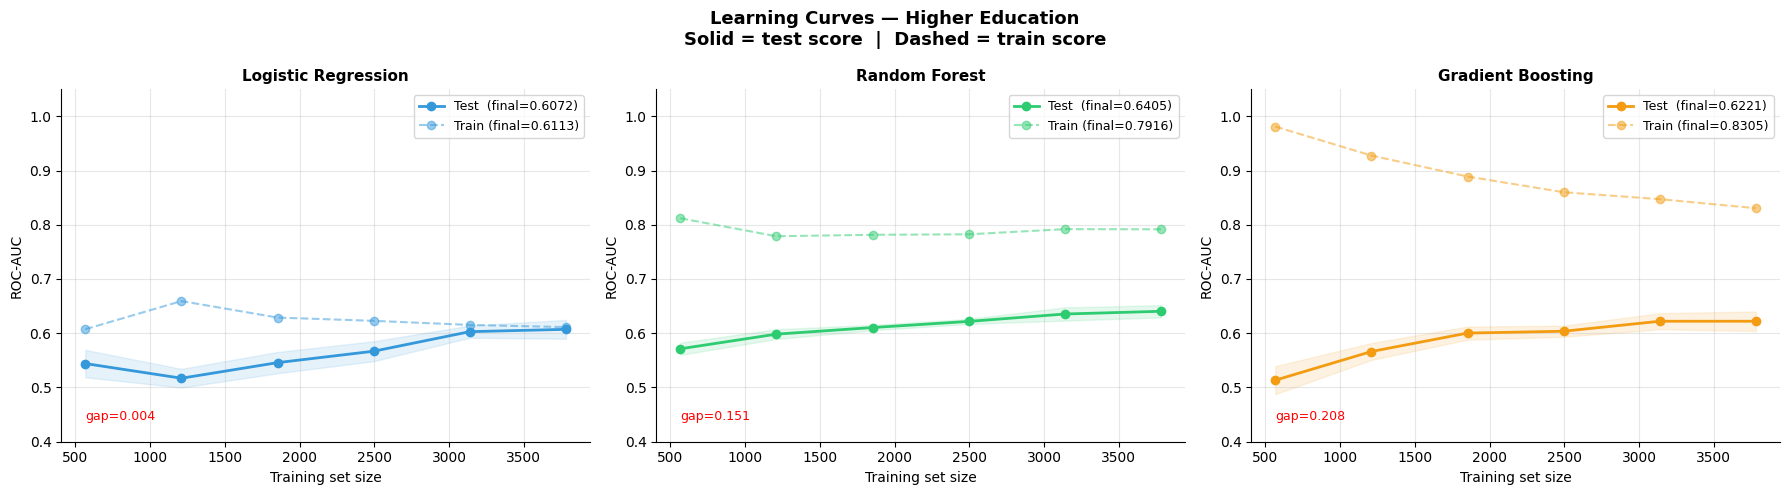

Saved: plot_learning_curves_he.png
  A Level or Below | Logistic Regression: 15%=0.5083 -> 100%=0.6465  gap=0.0014
  A Level or Below | Random Forest: 15%=0.5942 -> 100%=0.6701  gap=0.0860
  A Level or Below | Gradient Boosting: 15%=0.5707 -> 100%=0.6740  gap=0.0492


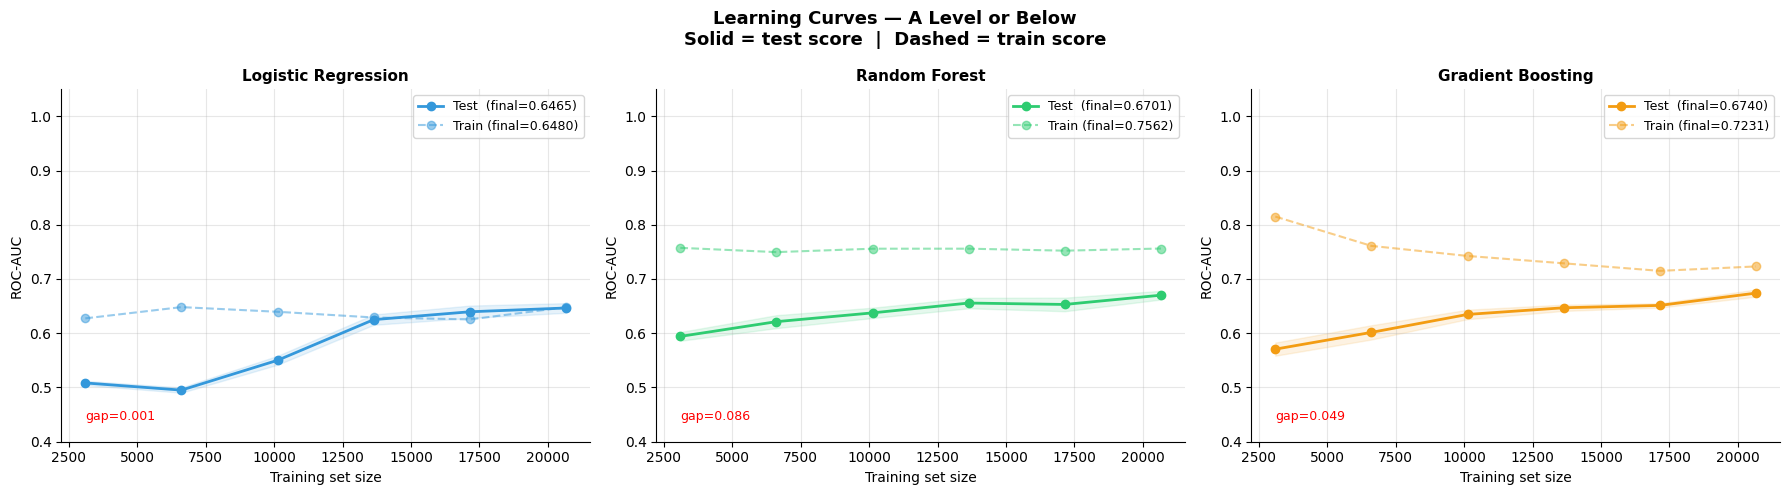

Saved: plot_learning_curves_al.png


In [12]:
section('STEP 10 — LEARNING CURVES')

lc_model_defs = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced', random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=RANDOM_SEED),
}
lc_palette = ['#3498db', '#2ecc71', '#f39c12']
cv4 = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_SEED)

print('Computing learning curves (3 models x 6 sizes x 4 folds per group)...')

for gname, gc in zip(GROUP_NAMES, GROUP_COLORS):
    gd = group_data[gname]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f'Learning Curves — {gname}\n'
        'Solid = test score  |  Dashed = train score',
        fontsize=13, fontweight='bold')

    for ax, (name, model_def), color in zip(axes, lc_model_defs.items(), lc_palette):
        train_sizes, train_scores, test_scores = learning_curve(
            model_def,
            gd['X_scaled_all'], gd['y'],
            train_sizes=np.linspace(0.15, 1.0, 6),
            cv=cv4, scoring='roc_auc',
            n_jobs=-1)

        tr_mean = train_scores.mean(axis=1)
        te_mean = test_scores.mean(axis=1)
        te_std  = test_scores.std(axis=1)

        ax.plot(train_sizes, te_mean, 'o-', color=color, lw=2,
                label=f'Test  (final={te_mean[-1]:.4f})')
        ax.plot(train_sizes, tr_mean, 'o--', color=color, lw=1.5, alpha=0.5,
                label=f'Train (final={tr_mean[-1]:.4f})')
        ax.fill_between(train_sizes,
                         te_mean - te_std, te_mean + te_std,
                         alpha=0.12, color=color)
        ax.set_title(name, fontweight='bold', fontsize=11)
        ax.set_xlabel('Training set size'); ax.set_ylabel('ROC-AUC')
        ax.set_ylim(0.4, 1.05)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
        gap = tr_mean[-1] - te_mean[-1]
        ax.text(train_sizes[0], 0.44, f'gap={gap:.3f}', fontsize=9, color='red')
        [ax.spines[s].set_visible(False) for s in ['top', 'right']]
        print(f'  {gname} | {name}: 15%={te_mean[0]:.4f} -> 100%={te_mean[-1]:.4f}  gap={gap:.4f}')

    plt.tight_layout()
    suffix = 'he' if gname == 'Higher Education' else 'al'
    plt.savefig(f'{OUTPUT_DIR}/plot_learning_curves_{suffix}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: plot_learning_curves_{suffix}.png')

# ─────────────────────────────────────────────────────────────────────────────
# 11. CROSS-GROUP ROC-AUC COMPARISON HEATMAP
# ─────────────────────────────────────────────────────────────────────────────


  STEP 11 — CROSS-GROUP COMPARISON HEATMAP


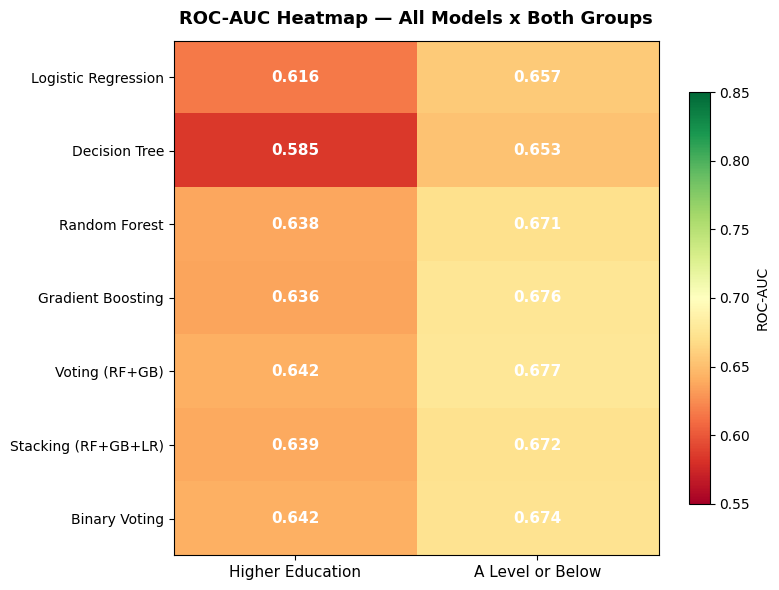

Saved: plot_heatmap_comparison.png


In [13]:
section('STEP 11 — CROSS-GROUP COMPARISON HEATMAP')

all_model_names = model_names + ['Voting (RF+GB)', 'Stacking (RF+GB+LR)', 'Binary Voting']

he_vals = ([group_data['Higher Education']['results'][m]['ROC_AUC'] for m in model_names] +
           [group_data['Higher Education']['roc_vote'],
            group_data['Higher Education']['roc_stack'],
            group_data['Higher Education']['roc_bin']])

al_vals = ([group_data['A Level or Below']['results'][m]['ROC_AUC'] for m in model_names] +
           [group_data['A Level or Below']['roc_vote'],
            group_data['A Level or Below']['roc_stack'],
            group_data['A Level or Below']['roc_bin']])

heat_df = pd.DataFrame(
    {'Higher Education': he_vals, 'A Level or Below': al_vals},
    index=all_model_names)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heat_df.values, cmap='RdYlGn', vmin=0.55, vmax=0.85, aspect='auto')
ax.set_xticks(range(2)); ax.set_xticklabels(GROUP_NAMES, fontsize=11)
ax.set_yticks(range(len(all_model_names)))
ax.set_yticklabels(all_model_names, fontsize=10)
ax.set_title('ROC-AUC Heatmap — All Models x Both Groups',
             fontsize=13, fontweight='bold', pad=12)
for i in range(len(all_model_names)):
    for j in range(2):
        val = heat_df.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='black' if val > 0.68 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8, label='ROC-AUC')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plot_heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_heatmap_comparison.png')

# ─────────────────────────────────────────────────────────────────────────────
# 12. FINAL SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

In [14]:
section('STEP 12 — FINAL SUMMARY')

for gname in GROUP_NAMES:
    gd = group_data[gname]
    print(f'\n{"="*70}')
    print(f'  GROUP: {gname}  (n={len(gd["X"]):,}, dropout rate={gd["y"].mean():.1%})')
    print(f'{"="*70}')

    summary_rows = []
    for name in model_names:
        summary_rows.append({
            'Model'       : name,
            'Accuracy'    : f"{gd['results'][name]['Accuracy']:.4f}",
            'F1 Weighted' : f"{gd['results'][name]['F1_Weighted']:.4f}",
            'ROC-AUC'     : f"{gd['results'][name]['ROC_AUC']:.4f}",
            'F1 Dropout'  : f"{gd['results'][name]['F1_Dropout']:.4f}",
            'CV F1 Mean'  : f"{gd['cv_scores'][name].mean():.4f}",
            'CV F1 Std'   : f"+-{gd['cv_scores'][name].std():.4f}",
            'Split'       : '80/20',
        })

    summary_rows.append({
        'Model'       : 'Voting (RF+GB)',
        'Accuracy'    : f"{accuracy_score(gd['y_test'], gd['y_pred_vote']):.4f}",
        'F1 Weighted' : f"{f1_score(gd['y_test'], gd['y_pred_vote'], average='weighted'):.4f}",
        'ROC-AUC'     : f"{gd['roc_vote']:.4f}",
        'F1 Dropout'  : f"{gd['f1d_vote']:.4f}",
        'CV F1 Mean'  : '—', 'CV F1 Std': '—', 'Split': '80/20',
    })
    summary_rows.append({
        'Model'       : 'Stacking (RF+GB+LR)',
        'Accuracy'    : f"{accuracy_score(gd['y_test'], gd['y_pred_stack']):.4f}",
        'F1 Weighted' : f"{f1_score(gd['y_test'], gd['y_pred_stack'], average='weighted'):.4f}",
        'ROC-AUC'     : f"{gd['roc_stack']:.4f}",
        'F1 Dropout'  : f"{gd['f1d_stack']:.4f}",
        'CV F1 Mean'  : '—', 'CV F1 Std': '—', 'Split': '80/20',
    })
    summary_rows.append({
        'Model'       : 'Binary Voting (Dropout vs rest)',
        'Accuracy'    : f"{gd['acc_bin']:.4f}",
        'F1 Weighted' : '—',
        'ROC-AUC'     : f"{gd['roc_bin']:.4f}  <- best",
        'F1 Dropout'  : f"{gd['f1_bin']:.4f}",
        'CV F1 Mean'  : '—', 'CV F1 Std': '—', 'Split': '80/20 binary',
    })

    summary_df = pd.DataFrame(summary_rows).set_index('Model')
    print('\n' + summary_df.to_string())

print('\n\nPLOTS SAVED:')
plots = [
    'plot_eda_he_al.png',
    'plot_metrics_he_al.png',
    'plot_confusion_he_al.png',
    'plot_roc_he_al.png',
    'plot_importance_he_al.png',
    'plot_tree_he.png',
    'plot_tree_al.png',
    'plot_cv_boxplot_he_al.png',
    'plot_ensemble_he.png',
    'plot_ensemble_al.png',
    'plot_ensemble_cm_he.png',
    'plot_ensemble_cm_al.png',
    'plot_binary_roc_he_al.png',
    'plot_full_cv_he.png',
    'plot_full_cv_al.png',
    'plot_learning_curves_he.png',
    'plot_learning_curves_al.png',
    'plot_heatmap_comparison.png',
]
for p in plots:
    print(f'  {OUTPUT_DIR}/{p}')

print('\nDone ✓')


  STEP 12 — FINAL SUMMARY

  GROUP: Higher Education  (n=5,043, dropout rate=26.9%)

                                Accuracy F1 Weighted          ROC-AUC F1 Dropout CV F1 Mean CV F1 Std         Split
Model                                                                                                              
Logistic Regression               0.6056      0.6256           0.6163     0.4232     0.5441  +-0.0095         80/20
Decision Tree                     0.5788      0.6013           0.5850     0.4023     0.5996  +-0.0193         80/20
Random Forest                     0.6363      0.6525           0.6376     0.4414     0.6798  +-0.0187         80/20
Gradient Boosting                 0.6283      0.6445           0.6364     0.4257     0.7021  +-0.0140         80/20
Voting (RF+GB)                    0.6293      0.6457           0.6424     0.4299          —         —         80/20
Stacking (RF+GB+LR)               0.6363      0.6512           0.6389     0.4292          —         — 